---

_You are currently looking at **version 1.1** of this notebook. To download notebooks and datafiles, as well as get help on Jupyter notebooks in the Coursera platform, visit the [Jupyter Notebook FAQ](https://www.coursera.org/learn/python-machine-learning/resources/bANLa) course resource._

---

# Applied Machine Learning: Module 2 (Supervised Learning, Part I)

## Preamble and Review

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

%matplotlib widget
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

np.set_printoptions(precision=2)


fruits = pd.read_table('assets/fruit_data_with_colors.txt')

# Variables predictoras (features)
feature_names_fruits = ['height', 'width', 'mass', 'color_score']
X_fruits = fruits[feature_names_fruits]

# Variable objetivo (label / clase)
y_fruits = fruits['fruit_label']

# Nombres humanos de las clases
# fruit_label: 1=apple, 2=mandarin, 3=orange, 4=lemon
target_names_fruits = ['apple', 'mandarin', 'orange', 'lemon']

# Se usan solo dos features para poder graficar en 2D
X_fruits_2d = fruits[['height', 'width']]
y_fruits_2d = fruits['fruit_label']

X_train, X_test, y_train, y_test = train_test_split(X_fruits, y_fruits, random_state=0)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
# Se AJUSTA el escalador SOLO con los datos de entrenamiento
# (aprende min y max de cada feature)
X_train_scaled = scaler.fit_transform(X_train)
# El set de prueba se transforma usando los mismos parámetros
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train_scaled, y_train)
# Accuracy sobre el conjunto de entrenamiento
print('Accuracy of K-NN classifier on training set: {:.2f}'
     .format(knn.score(X_train_scaled, y_train)))
# Accuracy sobre el conjunto de prueba
print('Accuracy of K-NN classifier on test set: {:.2f}'
     .format(knn.score(X_test_scaled, y_test)))

# PREDICCIÓN DE UN NUEVO EJEMPLO
example_fruit = [[5.5, 2.2, 10, 0.70]]
example_fruit_scaled = scaler.transform(example_fruit)
print('Predicted fruit type for ', example_fruit, ' is ', 
          target_names_fruits[knn.predict(example_fruit_scaled)[0]-1])

C:\Users\mar_c\AppData\Local\Temp\ipykernel_2384\153205100.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Accuracy of K-NN classifier on training set: 0.95
Accuracy of K-NN classifier on test set: 1.00
Predicted fruit type for  [[5.5, 2.2, 10, 0.7]]  is  mandarin


c:\Users\mar_c\OneDrive\Documentos\LosProyectos\Machine Learning\Aprendizaje Automatico\aprendizajeaut\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


## Crea diferentes tipos de Datasets

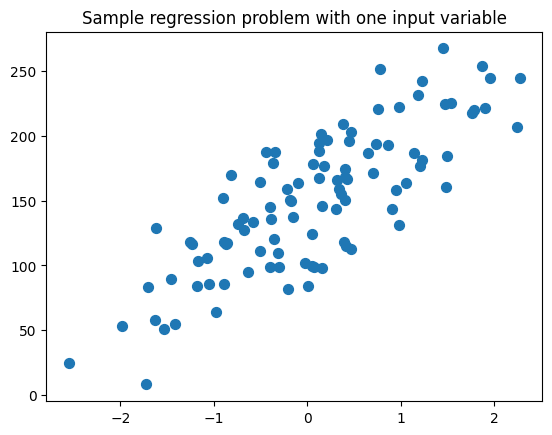

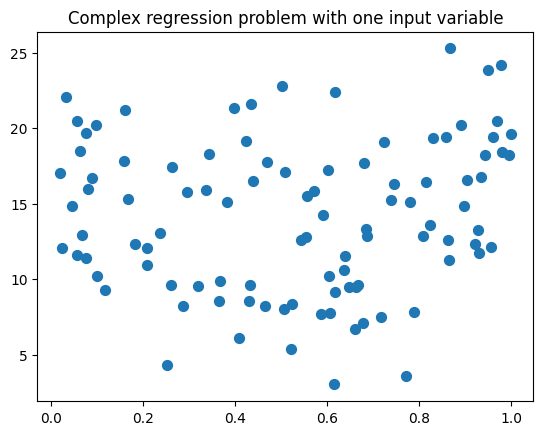

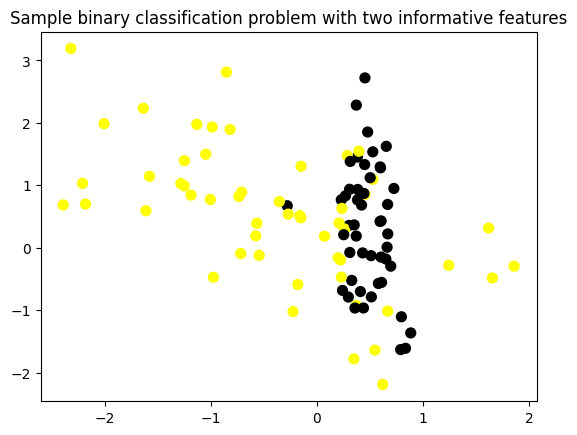

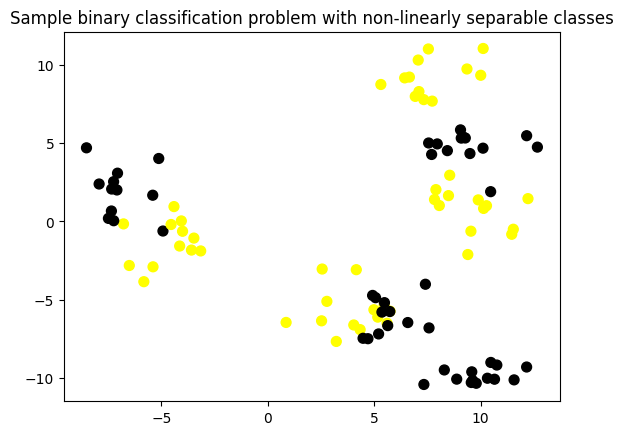

In [2]:
from sklearn.datasets import make_classification, make_blobs
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_breast_cancer
from adspy_shared_utilities import load_crime_dataset

cmap_bold = ListedColormap(['#FFFF00', '#00FF00', '#0000FF','#000000'])


# synthetic dataset for simple regression
from sklearn.datasets import make_regression
plt.figure()
plt.title('Sample regression problem with one input variable')
X_R1, y_R1 = make_regression(n_samples = 100, n_features=1,
                            n_informative=1, bias = 150.0,
                            noise = 30, random_state=0)
plt.scatter(X_R1, y_R1, marker= 'o', s=50)
plt.show()


# synthetic dataset for more complex regression
from sklearn.datasets import make_friedman1
plt.figure()
plt.title('Complex regression problem with one input variable')
X_F1, y_F1 = make_friedman1(n_samples = 100,
                           n_features = 7, random_state=0)

plt.scatter(X_F1[:, 2], y_F1, marker= 'o', s=50)
plt.show()

# synthetic dataset for classification (binary) 
plt.figure()
plt.title('Sample binary classification problem with two informative features')
X_C2, y_C2 = make_classification(n_samples = 100, n_features=2,
                                n_redundant=0, n_informative=2,
                                n_clusters_per_class=1, flip_y = 0.1,
                                class_sep = 0.5, random_state=0)
plt.scatter(X_C2[:, 0], X_C2[:, 1], c=y_C2,
           marker= 'o', s=50, cmap=cmap_bold)
plt.show()


# more difficult synthetic dataset for classification (binary) 
# with classes that are not linearly separable
X_D2, y_D2 = make_blobs(n_samples = 100, n_features = 2, centers = 8,
                       cluster_std = 1.3, random_state = 4)
y_D2 = y_D2 % 2
plt.figure()
plt.title('Sample binary classification problem with non-linearly separable classes')
plt.scatter(X_D2[:,0], X_D2[:,1], c=y_D2,
           marker= 'o', s=50, cmap=cmap_bold)
plt.show()


# Breast cancer dataset for classification
cancer = load_breast_cancer()
(X_cancer, y_cancer) = load_breast_cancer(return_X_y = True)


# Communities and Crime dataset
(X_crime, y_crime) = load_crime_dataset()

## K-Nearest Neighbors

### Classification

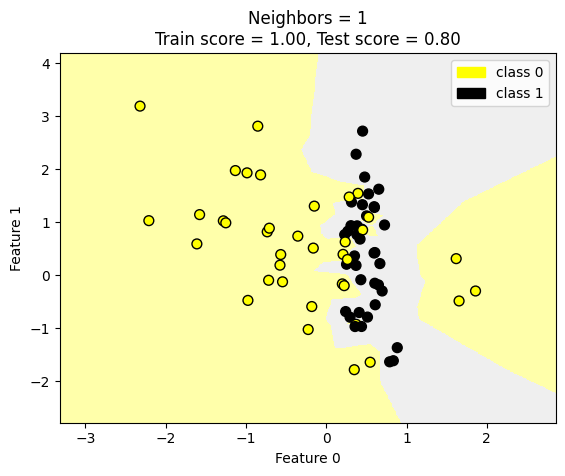

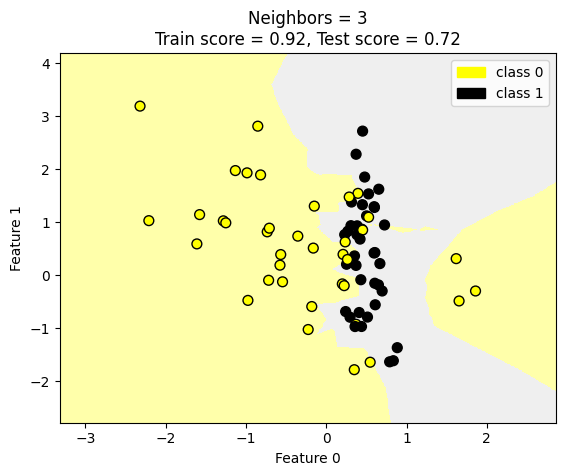

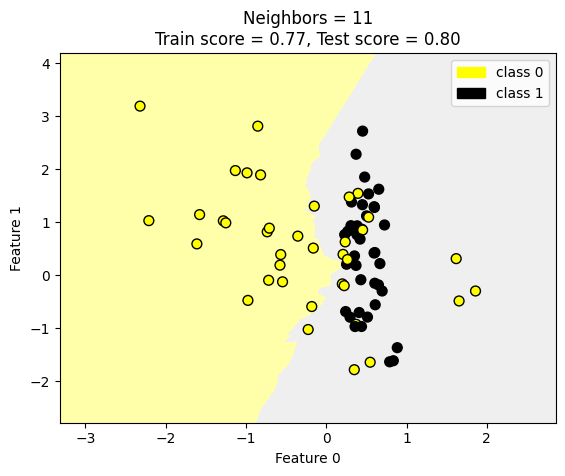

In [ ]:
from adspy_shared_utilities import plot_two_class_knn

X_train, X_test, y_train, y_test = train_test_split(X_C2, y_C2,
                                                   random_state=0)
## El plot_two_class_knn Se usa en problemas binarios cuando ya tiene una etiqueta de valor 0 y 1, pero solo uso didactico, ya que incluye solo 2 features
plot_two_class_knn(X_train, y_train, 1, 'uniform', X_test, y_test)
plot_two_class_knn(X_train, y_train, 3, 'uniform', X_test, y_test)
plot_two_class_knn(X_train, y_train, 11, 'uniform', X_test, y_test)

### Regression

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

X_train, X_test, y_train, y_test = train_test_split(X_R1, y_R1, random_state = 0)

# Se crea un modelo KNN para REGRESIÓN
knnreg = KNeighborsRegressor(n_neighbors = 5).fit(X_train, y_train)
# Se generan predicciones para el conjunto de prueba
print(knnreg.predict(X_test))
print('R-squared test score: {:.3f}'
     .format(knnreg.score(X_test, y_test)))

[231.71 148.36 150.59 150.59  72.15 166.51 141.91 235.57 208.26 102.1
 191.32 134.5  228.32 148.36 159.17 113.47 144.04 199.23 143.19 166.51
 231.71 208.26 128.02 123.14 141.91]
R-squared test score: 0.425


| R²        | Interpretación             |
| --------- | -------------------------- |
| < 0       | Peor que predecir la media |
| 0 – 0.3   | Modelo muy débil           |
| 0.3 – 0.6 | Modelo mediocre / parcial  |
| 0.6 – 0.8 | Modelo decente             |
| > 0.8     | Modelo fuerte              |

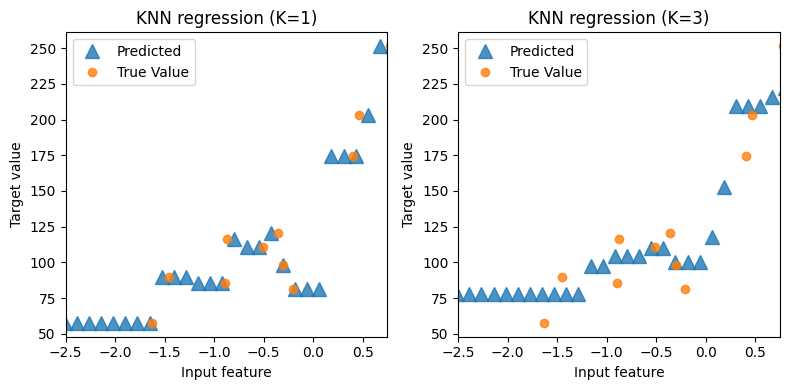

In [5]:
fig, subaxes = plt.subplots(1, 2, figsize=(8,4))
X_predict_input = np.linspace(-3, 3, 50).reshape(-1,1)
X_train, X_test, y_train, y_test = train_test_split(X_R1[0::5], y_R1[0::5], random_state = 0)

for thisaxis, K in zip(subaxes, [1, 3]):
    knnreg = KNeighborsRegressor(n_neighbors = K).fit(X_train, y_train)
    y_predict_output = knnreg.predict(X_predict_input)
    thisaxis.set_xlim([-2.5, 0.75])
    thisaxis.plot(X_predict_input, y_predict_output, '^', markersize = 10,
                 label='Predicted', alpha=0.8)
    thisaxis.plot(X_train, y_train, 'o', label='True Value', alpha=0.8)
    thisaxis.set_xlabel('Input feature')
    thisaxis.set_ylabel('Target value')
    thisaxis.set_title('KNN regression (K={})'.format(K))
    thisaxis.legend()
plt.tight_layout()

### Regression model complexity as a function of K

Este código muestra cómo el parámetro K en KNN Regression controla la complejidad del modelo, visualizando simultáneamente la función aprendida y el desempeño en entrenamiento y prueba para evidenciar el bias–variance tradeoff.

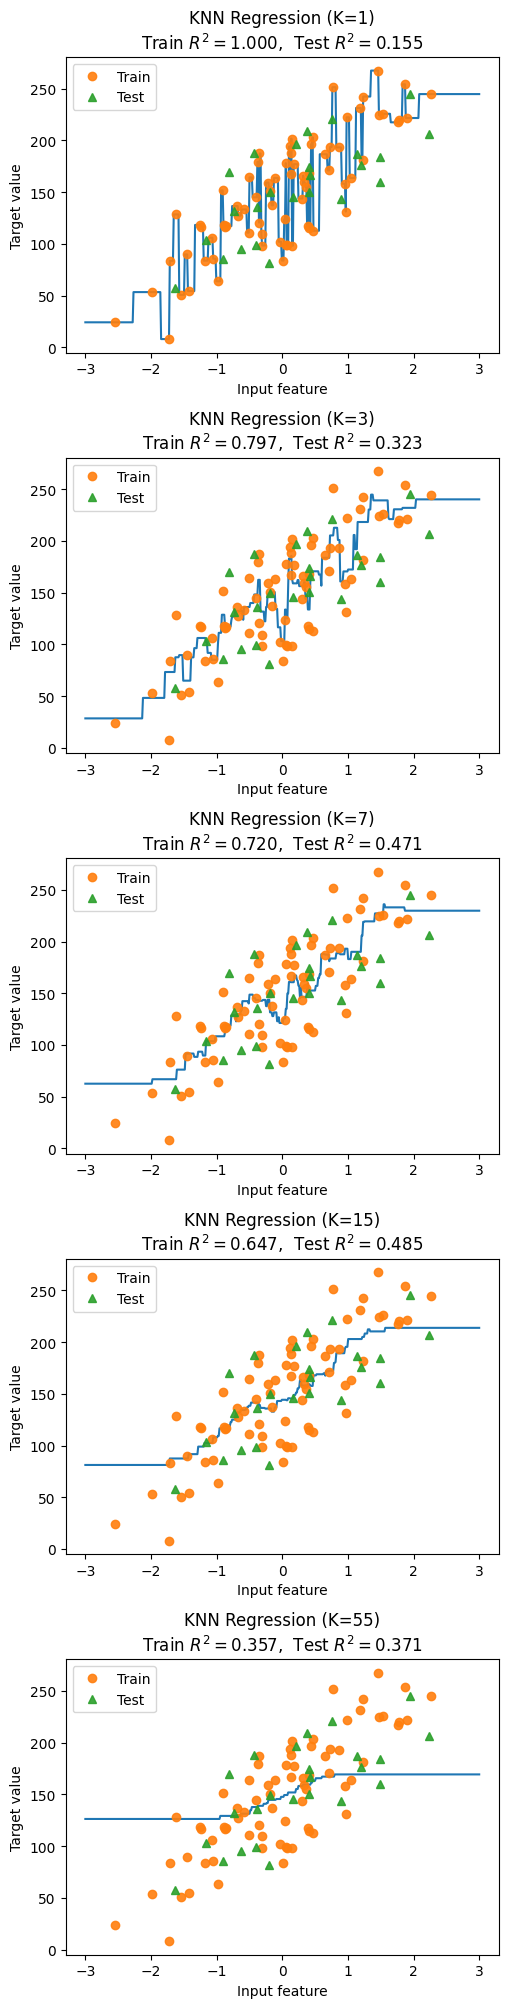

In [ ]:
# Se crean 5 subgráficas verticales (una por cada valor de K)
fig, subaxes = plt.subplots(5, 1, figsize=(5,20))
X_predict_input = np.linspace(-3, 3, 500).reshape(-1,1)
X_train, X_test, y_train, y_test = train_test_split(X_R1, y_R1,
                                                   random_state = 0)

# Se prueban distintos valores de K (desde muy pequeño a muy grande)
for thisaxis, K in zip(subaxes, [1, 3, 7, 15, 55]):
    knnreg = KNeighborsRegressor(n_neighbors = K).fit(X_train, y_train)
    # Predicciones continuas para dibujar la curva aprendida
    y_predict_output = knnreg.predict(X_predict_input)
    # R² sobre entrenamiento y prueba
    train_score = knnreg.score(X_train, y_train)
    test_score = knnreg.score(X_test, y_test)
    # Curva de predicción
    thisaxis.plot(X_predict_input, y_predict_output)
    # Puntos de entrenamiento
    thisaxis.plot(X_train, y_train, 'o', alpha=0.9, label='Train')
    # Puntos de prueba
    thisaxis.plot(X_test, y_test, '^', alpha=0.9, label='Test')
    thisaxis.set_xlabel('Input feature')
    thisaxis.set_ylabel('Target value')
    thisaxis.set_title('KNN Regression (K={})\n\
Train $R^2 = {:.3f}$,  Test $R^2 = {:.3f}$'
                      .format(K, train_score, test_score))
    thisaxis.legend()
    plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)


## Linear models for regression

### Linear regression

La regresión lineal calcula el peso y el intercepto minimizando el error en el conjunto de entrenamiento; el conjunto de prueba se usa únicamente para evaluar qué tan bien generaliza el modelo.

In [7]:
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X_R1, y_R1,
                                                   random_state = 0)
linreg = LinearRegression().fit(X_train, y_train)

print('linear model coeff (w): {}'
     .format(linreg.coef_))
print('linear model intercept (b): {:.3f}'
     .format(linreg.intercept_))
print('R-squared score (training): {:.3f}'
     .format(linreg.score(X_train, y_train)))
print('R-squared score (test): {:.3f}'
     .format(linreg.score(X_test, y_test)))

linear model coeff (w): [45.71]
linear model intercept (b): 148.446
R-squared score (training): 0.679
R-squared score (test): 0.492


### Linear regression: example plot 

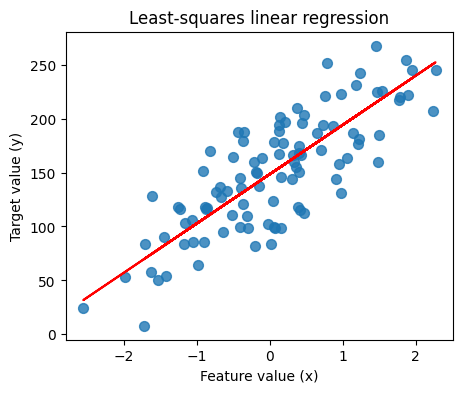

In [8]:
plt.figure(figsize=(5,4))
plt.scatter(X_R1, y_R1, marker= 'o', s=50, alpha=0.8)
plt.plot(X_R1, linreg.coef_ * X_R1 + linreg.intercept_, 'r-')
plt.title('Least-squares linear regression')
plt.xlabel('Feature value (x)')
plt.ylabel('Target value (y)')
plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_crime, y_crime,
                                                   random_state = 0)
linreg = LinearRegression().fit(X_train, y_train)

print('Crime dataset')
print('linear model intercept: {}'
     .format(linreg.intercept_))
print('linear model coeff:\n{}'
     .format(linreg.coef_))
print('R-squared score (training): {:.3f}'
     .format(linreg.score(X_train, y_train)))
print('R-squared score (test): {:.3f}'
     .format(linreg.score(X_test, y_test)))

Crime dataset
linear model intercept: -1728.1306726026442
linear model coeff:
[ 1.62e-03 -9.43e+01  1.36e+01 -3.13e+01 -8.15e-02 -1.69e+01 -2.43e-03
  1.53e+00 -1.39e-02 -7.72e+00  2.28e+01 -5.66e+00  9.35e+00  2.07e-01
 -7.43e+00  9.66e-03  4.38e-03  4.80e-03 -4.46e+00 -1.61e+01  8.83e+00
 -5.07e-01 -1.42e+00  8.18e+00 -3.87e+00 -3.54e+00  4.49e+00  9.31e+00
  1.74e+02  1.18e+01  1.51e+02 -3.30e+02 -1.35e+02  6.95e-01 -2.38e+01
  2.77e+00  3.82e-01  4.39e+00 -1.06e+01 -4.92e-03  4.14e+01 -1.16e-03
  1.19e+00  1.75e+00 -3.68e+00  1.60e+00 -8.42e+00 -3.80e+01  4.74e+01
 -2.51e+01 -2.88e-01 -3.66e+01  1.90e+01 -4.53e+01  6.83e+02  1.04e+02
 -3.29e+02 -3.14e+01  2.74e+01  5.12e+00  6.92e+01  1.98e-02 -6.12e-01
  2.65e+01  1.01e+01 -1.59e+00  2.24e+00  7.38e+00 -3.14e+01 -9.78e-05
  5.02e-05 -3.48e-04 -2.50e-04 -5.27e-01 -5.17e-01 -4.10e-01  1.16e-01
  1.46e+00 -3.04e-01  2.44e+00 -3.66e+01  1.41e-01  2.89e-01  1.77e+01
  5.97e-01  1.98e+00 -1.36e-01 -1.85e+00]
R-squared score (training): 

### Ridge regression

In [10]:
from sklearn.linear_model import Ridge
X_train, X_test, y_train, y_test = train_test_split(X_crime, y_crime,
                                                   random_state = 0)

linridge = Ridge(alpha=20.0).fit(X_train, y_train)

print('Crime dataset')
print('ridge regression linear model intercept: {}'
     .format(linridge.intercept_))
print('ridge regression linear model coeff:\n{}'
     .format(linridge.coef_))
print('R-squared score (training): {:.3f}'
     .format(linridge.score(X_train, y_train)))
print('R-squared score (test): {:.3f}'
     .format(linridge.score(X_test, y_test)))
print('Number of non-zero features: {}'
     .format(np.sum(linridge.coef_ != 0)))

Crime dataset
ridge regression linear model intercept: -3352.4230358460895
ridge regression linear model coeff:
[ 1.95e-03  2.19e+01  9.56e+00 -3.59e+01  6.36e+00 -1.97e+01 -2.81e-03
  1.66e+00 -6.61e-03 -6.95e+00  1.72e+01 -5.63e+00  8.84e+00  6.79e-01
 -7.34e+00  6.70e-03  9.79e-04  5.01e-03 -4.90e+00 -1.79e+01  9.18e+00
 -1.24e+00  1.22e+00  1.03e+01 -3.78e+00 -3.73e+00  4.75e+00  8.43e+00
  3.09e+01  1.19e+01 -2.05e+00 -3.82e+01  1.85e+01  1.53e+00 -2.20e+01
  2.46e+00  3.29e-01  4.02e+00 -1.13e+01 -4.70e-03  4.27e+01 -1.23e-03
  1.41e+00  9.35e-01 -3.00e+00  1.12e+00 -1.82e+01 -1.55e+01  2.42e+01
 -1.32e+01 -4.20e-01 -3.60e+01  1.30e+01 -2.81e+01  4.39e+01  3.87e+01
 -6.46e+01 -1.64e+01  2.90e+01  4.15e+00  5.34e+01  1.99e-02 -5.47e-01
  1.24e+01  1.04e+01 -1.57e+00  3.16e+00  8.78e+00 -2.95e+01 -2.33e-04
  3.14e-04 -4.13e-04 -1.80e-04 -5.74e-01 -5.18e-01 -4.21e-01  1.53e-01
  1.33e+00  3.85e+00  3.03e+00 -3.78e+01  1.38e-01  3.08e-01  1.57e+01
  3.31e-01  3.36e+00  1.61e-01 -2.68

#### Ridge regression with feature normalization

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

from sklearn.linear_model import Ridge
X_train, X_test, y_train, y_test = train_test_split(X_crime, y_crime,
                                                   random_state = 0)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Se crea y entrena un modelo Ridge Regression
# alpha=20.0 controla la fuerza de la regularización L2
linridge = Ridge(alpha=20.0).fit(X_train_scaled, y_train)

print('Crime dataset')
# Intercepto del modelo (bias)
print('ridge regression linear model intercept: {}'
     .format(linridge.intercept_))
# Coeficientes del modelo
print('ridge regression linear model coeff:\n{}'
     .format(linridge.coef_))
# Indica qué tanto explica el modelo los datos vistos
print('R-squared score (training): {:.3f}'
     .format(linridge.score(X_train_scaled, y_train)))
# Indica qué tan bien generaliza el modelo
print('R-squared score (test): {:.3f}'
     .format(linridge.score(X_test_scaled, y_test)))
# Número de features con coeficiente distinto de cero
# En Ridge normalmente TODAS las variables siguen activas, no elimina nignuna ya que le da un peso a todas
print('Number of non-zero features: {}'
     .format(np.sum(linridge.coef_ != 0)))

Crime dataset
ridge regression linear model intercept: 933.3906385044165
ridge regression linear model coeff:
[  88.69   16.49  -50.3   -82.91  -65.9    -2.28   87.74  150.95   18.88
  -31.06  -43.14 -189.44   -4.53  107.98  -76.53    2.86   34.95   90.14
   52.46  -62.11  115.02    2.67    6.94   -5.67 -101.55  -36.91   -8.71
   29.12  171.26   99.37   75.07  123.64   95.24 -330.61 -442.3  -284.5
 -258.37   17.66 -101.71  110.65  523.14   24.82    4.87  -30.47   -3.52
   50.58   10.85   18.28   44.11   58.34   67.09  -57.94  116.14   53.81
   49.02   -7.62   55.14  -52.09  123.39   77.13   45.5   184.91  -91.36
    1.08  234.09   10.39   94.72  167.92  -25.14   -1.18   14.6    36.77
   53.2   -78.86   -5.9    26.05  115.15   68.74   68.29   16.53  -97.91
  205.2    75.97   61.38  -79.83   67.27   95.67  -11.88]
R-squared score (training): 0.615
R-squared score (test): 0.599
Number of non-zero features: 88


#### Ridge regression with regularization parameter: alpha

In [12]:
print('Ridge regression: effect of alpha regularization parameter\n')
for this_alpha in [0, 1, 10, 20, 50, 100, 1000]:
    linridge = Ridge(alpha = this_alpha).fit(X_train_scaled, y_train)
    r2_train = linridge.score(X_train_scaled, y_train)
    r2_test = linridge.score(X_test_scaled, y_test)
    num_coeff_bigger = np.sum(abs(linridge.coef_) > 1.0)
    print('Alpha = {:.2f}\nnum abs(coeff) > 1.0: {}, \
r-squared training: {:.2f}, r-squared test: {:.2f}\n'
         .format(this_alpha, num_coeff_bigger, r2_train, r2_test))

Ridge regression: effect of alpha regularization parameter

Alpha = 0.00
num abs(coeff) > 1.0: 88, r-squared training: 0.67, r-squared test: 0.50

Alpha = 1.00
num abs(coeff) > 1.0: 87, r-squared training: 0.66, r-squared test: 0.56

Alpha = 10.00
num abs(coeff) > 1.0: 87, r-squared training: 0.63, r-squared test: 0.59

Alpha = 20.00
num abs(coeff) > 1.0: 88, r-squared training: 0.61, r-squared test: 0.60

Alpha = 50.00
num abs(coeff) > 1.0: 86, r-squared training: 0.58, r-squared test: 0.58

Alpha = 100.00
num abs(coeff) > 1.0: 87, r-squared training: 0.55, r-squared test: 0.55

Alpha = 1000.00
num abs(coeff) > 1.0: 84, r-squared training: 0.31, r-squared test: 0.30



c:\Users\mar_c\OneDrive\Documentos\LosProyectos\Machine Learning\Aprendizaje Automatico\aprendizajeaut\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.13918e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


### Lasso regression

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train, X_test, y_train, y_test = train_test_split(X_crime, y_crime,
                                                   random_state = 0)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Se crea y entrena el modelo Lasso
# alpha=2.0 controla la fuerza de la regularización L1
# max_iter alto porque Lasso converge más lento
linlasso = Lasso(alpha=2.0, max_iter = 10000).fit(X_train_scaled, y_train)

print('Crime dataset')
# Intercepto (bias)
print('lasso regression linear model intercept: {}'
     .format(linlasso.intercept_))
# Coeficientes del modelo
# Muchos serán EXACTAMENTE 0
print('lasso regression linear model coeff:\n{}'
     .format(linlasso.coef_))
# Número de variables que el modelo decidió conservar
print('Non-zero features: {}'
     .format(np.sum(linlasso.coef_ != 0)))
# R² en entrenamiento
print('R-squared score (training): {:.3f}'
     .format(linlasso.score(X_train_scaled, y_train)))
# R² en test    
print('R-squared score (test): {:.3f}\n'
     .format(linlasso.score(X_test_scaled, y_test)))
# Se listan SOLO las variables con peso distinto de cero,
# ordenadas por importancia absoluta
print('Features with non-zero weight (sorted by absolute magnitude):')

for e in sorted (list(zip(list(X_crime), linlasso.coef_)),
                key = lambda e: -abs(e[1])):
    if e[1] != 0:
        print('\t{}, {:.3f}'.format(e[0], e[1]))

# El biases mayor que en Ridge porque hay menos variables a utilizar
# Solo sobreviven 20 de 88 variables y obtiene un mejor score que Ridge

Crime dataset
lasso regression linear model intercept: 1186.612061998579
lasso regression linear model coeff:
[    0.       0.      -0.    -168.18    -0.      -0.       0.     119.69
     0.      -0.       0.    -169.68    -0.       0.      -0.       0.
     0.       0.      -0.      -0.       0.      -0.       0.       0.
   -57.53    -0.      -0.       0.     259.33    -0.       0.       0.
     0.      -0.   -1188.74    -0.      -0.      -0.    -231.42     0.
  1488.37     0.      -0.      -0.      -0.       0.       0.       0.
     0.       0.      -0.       0.      20.14     0.       0.       0.
     0.       0.     339.04     0.       0.     459.54    -0.       0.
   122.69    -0.      91.41     0.      -0.       0.       0.      73.14
     0.      -0.       0.       0.      86.36     0.       0.       0.
  -104.57   264.93     0.      23.45   -49.39     0.       5.2      0.  ]
Non-zero features: 20
R-squared score (training): 0.631
R-squared score (test): 0.624

Features with n

#### Lasso regression with regularization parameter: alpha

In [14]:
print('Lasso regression: effect of alpha regularization\n\
parameter on number of features kept in final model\n')

for alpha in [0.5, 1, 2, 3, 5, 10, 20, 50]:
    linlasso = Lasso(alpha, max_iter = 10000).fit(X_train_scaled, y_train)
    r2_train = linlasso.score(X_train_scaled, y_train)
    r2_test = linlasso.score(X_test_scaled, y_test)
    
    print('Alpha = {:.2f}\nFeatures kept: {}, r-squared training: {:.2f}, \
r-squared test: {:.2f}\n'
         .format(alpha, np.sum(linlasso.coef_ != 0), r2_train, r2_test))

Lasso regression: effect of alpha regularization
parameter on number of features kept in final model

Alpha = 0.50
Features kept: 35, r-squared training: 0.65, r-squared test: 0.58

Alpha = 1.00
Features kept: 25, r-squared training: 0.64, r-squared test: 0.60

Alpha = 2.00
Features kept: 20, r-squared training: 0.63, r-squared test: 0.62

Alpha = 3.00
Features kept: 17, r-squared training: 0.62, r-squared test: 0.63

Alpha = 5.00
Features kept: 12, r-squared training: 0.60, r-squared test: 0.61

Alpha = 10.00
Features kept: 6, r-squared training: 0.57, r-squared test: 0.58

Alpha = 20.00
Features kept: 2, r-squared training: 0.51, r-squared test: 0.50

Alpha = 50.00
Features kept: 1, r-squared training: 0.31, r-squared test: 0.30



### Polynomial regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures


# ======================================================
# 1) REGRESIÓN LINEAL "NORMAL" EN UN PROBLEMA COMPLEJO
# ======================================================

X_train, X_test, y_train, y_test = train_test_split(X_F1, y_F1,
                                                   random_state = 0)
linreg = LinearRegression().fit(X_train, y_train)

print('linear model coeff (w): {}'
     .format(linreg.coef_))
print('linear model intercept (b): {:.3f}'
     .format(linreg.intercept_))
print('R-squared score (training): {:.3f}'
     .format(linreg.score(X_train, y_train)))
print('R-squared score (test): {:.3f}'
     .format(linreg.score(X_test, y_test)))


# ======================================================
# 2) TRANSFORMACIÓN A FEATURES POLINOMIALES (GRADO 2)
# ======================================================

print('\nNow we transform the original input data to add\n\
polynomial features up to degree 2 (quadratic)\n')

Dijiste:
Ahora estamos haciendo el curso de aprendizaje automatico de la universidad de michigan en Coursera

ChatGPT dijo:
Correcto. El curso de Aprendizaje Automático de la Universidad de Michigan en Coursera es una buena elección para tu nivel actual, pero conviene aclarar qué es y qué no es, para que lo aproveches bien y no tengas expectativas equivocadas.

Qué tipo de curso es (importante)
Este curso está más orientado a ML aplicado y análisis predictivo clásico, no a deep learning ni a modelos financieros avanzados. Es ideal como puente entre:

análisis descriptivo / EDA

y modelos predictivos reales en Python

No sustituye a Andrew Ng, lo complementa.

Qué deberías estar aprendiendo aquí (y por qué importa)
Mientras avances en el curso, asegúrate de dominar explícitamente estos puntos:

1. Flujo correcto de análisis predictivo
No solo el modelo:

Definición del problema (qué predices y para qué)

Selección de variables (features)

Train / validation / test split (y por qué)

Entrenamiento

Evaluación correcta

Interpretación de resultados

Si el curso solo se sigue “porque sí”, se desaprovecha.

2. Modelos clave que sí debes entender bien
En este curso, lo crítico no es memorizar código sino entender cuándo usar cada uno:

Regresión lineal y logística

k-NN

Árboles de decisión

Random Forest

SVM (a nivel conceptual)

Si en algún punto piensas “todos hacen lo mismo”, ahí hay un error conceptual que hay que corregir.

3. Métricas (aquí mucha gente se equivoca)
Debes tener claro:

Regresión: MAE, MSE, RMSE, R²

Clasificación: accuracy, precision, recall, F1, ROC-AUC

👉 Error común: usar accuracy cuando el dataset está desbalanceado.
Si el curso no lo enfatiza, tú sí debes hacerlo.

Cómo deberías complementar ESTE curso (muy importante)
Paralelo al curso, haz esto en Python:

Práctica mínima recomendada
Un dataset time-series financiero (precios, ingresos, FCF)

Un dataset tabular clásico (Kaggle/UCI)

Para cada uno:

al menos 2 modelos distintos

comparación de métricas

conclusión clara: cuál usarías y por qué

Si no haces esto, el curso se queda en teoría aplicada.

Qué NO cubre bien este curso (y vendrá después)
No esperes aprender aquí:

ARIMA / SARIMA

Prophet

LSTM

Feature engineering financiero avanzado

Backtesting serio

Eso viene después, no ahora.

Siguiente paso cuando termines Michigan
El camino lógico será:

scikit-learn sólido (pipelines, GridSearch, cross-validation)

Time series forecasting (statsmodels + Prophet)

Luego sí: LSTM / deep learning para series financieras

Si quieres, en el siguiente mensaje puedo:

decirte qué módulos del curso de Michigan son clave y cuáles puedes pasar más rápido, o

ayudarte a diseñar un mini-proyecto predictivo en paralelo al curso para que realmente subas de nivel.


Dijiste:
como hago este codigo?

# You should write your whole answer within the function provided. The autograder will call
# this function and compare the return value against the correct solution value
def answer_zero():
    # This function returns the number of features of the breast cancer dataset, which is an integer. 
    # The assignment question description will tell you the general format the autograder is expecting
    
    # YOUR CODE HERE
    raise NotImplementedError()

ChatGPT dijo:
Este ejercicio es directo. No debes sobrepensarlo.

La función debe:

Cargar el dataset breast cancer de sklearn

Obtener el número de features

Devolver ese número como entero

El error típico aquí es intentar contar filas o usar el target. Solo cuentan las columnas de entrada (X).

Implementación correcta
def answer_zero():
    from sklearn.datasets import load_breast_cancer
    
    cancer = load_breast_cancer()
    return cancer.data.shape[1]
Por qué esto es correcto
cancer.data → matriz (n_samples, n_features)

shape[1] → número de features

El autograder espera solo un entero, nada más

Valor que devuelve
30
Si hubieras devuelto:

len(cancer.feature_names) → también válido

shape[0] → incorrecto (eso son observaciones, no features)

Si quieres, mándame el siguiente ejercicio y lo resolvemos explicando el razonamiento que buscan los graders, no solo el código.


Dijiste:
Convert the sklearn.dataset cancer to a DataFrame.
def answer_one():
    # YOUR CODE HERE
    raise NotImplementedError()

ChatGPT dijo:
Aquí el error más común es devolver solo cancer.data o mezclar el target.
La consigna es convertir el dataset a DataFrame, lo que implica features + nombres de columnas, no el target.

Implementación correcta
def answer_one():
    import pandas as pd
    from sklearn.datasets import load_breast_cancer
    
    cancer = load_breast_cancer()
    df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
    return df
Por qué esta es la solución que espera el autograder
cancer.data → solo variables predictoras

columns=cancer.feature_names → nombres correctos

Se devuelve un DataFrame, no un array

Qué NO hacer (errores típicos)
❌ Incluir el target (cancer.target)

❌ No poner nombres de columnas

❌ Devolver un numpy.ndarray

El target se agrega en el siguiente ejercicio, no aquí.

Cuando quieras, pasa el siguiente enunciado y seguimos.


Dijiste:
What is the class distribution? (i.e. how many instances of malignant and how many benign?)

This function should return a Series named target of length 2 with integer values and index = ['malignant', 'benign']

ChatGPT dijo:
Aquí sí debes usar el target. La clave es devolver una Series con nombre, índices correctos y valores enteros. El autograder es estricto con eso.

Implementación correcta
def answer_two():
    import pandas as pd
    from sklearn.datasets import load_breast_cancer
    
    cancer = load_breast_cancer()
    
    target_series = pd.Series(cancer.target)
    counts = target_series.value_counts().sort_index()
    
    counts.index = ['malignant', 'benign']
    counts.name = 'target'
    
    return counts
Por qué esto es lo que espera el autograder
cancer.target:

0 → malignant

1 → benign

value_counts().sort_index() mantiene el orden correcto

Se renombran los índices exactamente como pide el enunciado

Se asigna name = 'target' (muchos fallan aquí)

Output esperado
malignant    212
benign       357
Name: target, dtype: int64
Errores comunes que te restan puntos
❌ Devolver un DataFrame en lugar de Series

❌ No nombrar la Series como target

❌ Índices como 0, 1 en vez de 'malignant', 'benign'

Pasa el siguiente ejercicio; normalmente aquí sigue agregar el target al DataFrame, y ahí también hay una trampa típica.


Dijiste:
Split the DataFrame into X (the data) and y (the labels).

This function should return a tuple of length 2: (X, y), where

X has shape (569, 30)
y has shape (569,).

ChatGPT dijo:
Aquí el punto clave es que X solo contiene las features y y es el target separado, manteniendo exactamente las dimensiones que pide el enunciado.
Muchos fallan por incluir el target dentro de X o por devolver arrays en lugar de objetos de pandas.

Implementación correcta
def answer_three():
    import pandas as pd
    from sklearn.datasets import load_breast_cancer
    
    cancer = load_breast_cancer()
    
    X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
    y = pd.Series(cancer.target)
    
    return X, y
Por qué cumple exactamente lo pedido
X.shape → (569, 30)

y.shape → (569,)

X es un DataFrame

y es una Series

No se mezclan labels con features

Errores típicos (corrigiéndote antes de que pases horas)
❌ X = df.iloc[:, :-1] cuando aún no existe el target en el DataFrame

❌ y = df['target'] sin haberlo creado

❌ Convertir todo a numpy (.values) → algunos graders lo penalizan

Este ejercicio es base para los siguientes (train/test split y modelos).
Cuando quieras, seguimos con el siguiente.


Dijiste:
como llamoa  esa funcion?

ChatGPT dijo:
No la “llamas” tú explícitamente en este ejercicio.

Lo que realmente pasa
El autograder llama automáticamente a answer_three()

Tú solo defines la función correctamente

No debes poner nada fuera de la función

Por ejemplo, esto es correcto:

def answer_three():
    import pandas as pd
    from sklearn.datasets import load_breast_cancer
    
    cancer = load_breast_cancer()
    
    X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
    y = pd.Series(cancer.target)
    
    return X, y
Si quieres probarla tú (solo para verificar)
En una celda aparte del notebook:

X, y = answer_three()
print(X.shape)
print(y.shape)
Output esperado:

(569, 30)
(569,)
Error común que debes evitar
❌ Escribir answer_three() fuera de una celda de prueba dentro del bloque evaluado

❌ Agregar print() dentro de la función (el autograder lo puede marcar como incorrecto)

Regla práctica en Coursera:

Define la función → devuelve lo pedido → nada más.

Cuando sigas con el siguiente ejercicio (train/test split o modelos), avísame y lo hacemos con el mismo criterio de autograder.


Dijiste:
Using train_test_split, split X and y into training and test sets (X_train, X_test, y_train, and y_test).

Set the random number generator state to 0 using random_state=0 to make sure your results match the autograder!

This function should return a tuple of length 4: (X_train, X_test, y_train, y_test), where

X_train has shape (426, 30)
X_test has shape (143, 30)
y_train has shape (426,)
y_test has shape (143,)

ChatGPT dijo:
Aquí sí hay una trampa típica: el test_size.
Si no usas el valor correcto, las dimensiones no van a coincidir con el autograder.

Implementación correcta
def answer_four():
    import pandas as pd
    from sklearn.datasets import load_breast_cancer
    from sklearn.model_selection import train_test_split
    
    cancer = load_breast_cancer()
    
    X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
    y = pd.Series(cancer.target)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        random_state=0
    )
    
    return X_train, X_test, y_train, y_test
Por qué NO se especifica test_size
train_test_split usa por defecto:

test_size = 0.25

25% de 569 ≈ 143

75% ≈ 426

Si pones test_size=0.2 o 0.3, fallas el ejercicio.

Dimensiones correctas
X_train → (426, 30)
X_test  → (143, 30)
y_train → (426,)
y_test  → (143,)
Errores comunes (te los corrijo antes)
❌ Olvidar random_state=0

❌ Usar stratify=y (no lo piden aquí)

❌ Devolver en otro orden

Este punto ya te mete en ML real.
El siguiente ejercicio casi seguro es entrenar un clasificador k-NN o Logistic Regression. Cuando lo tengas, pásalo.


Dijiste:
Using KNeighborsClassifier, fit a k-nearest neighbors (knn) classifier with X_train, y_train and using one nearest neighbor (n_neighbors = 1).

*This function should return a sklearn.neighbors.classification.KNeighborsClassifier.

ChatGPT dijo:
Aquí es muy directo, pero hay dos errores típicos que hacen fallar el autograder:

No entrenar el modelo (fit)

Devolver predicciones en lugar del clasificador

Implementación correcta
def answer_five():
    from sklearn.datasets import load_breast_cancer
    from sklearn.model_selection import train_test_split
    from sklearn.neighbors import KNeighborsClassifier
    import pandas as pd
    
    cancer = load_breast_cancer()
    
    X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
    y = pd.Series(cancer.target)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        random_state=0
    )
    
    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_train, y_train)
    
    return knn
Por qué esto es lo que espera Coursera
n_neighbors=1 exactamente

Se usa X_train, y_train

Se devuelve el objeto entrenado, no accuracy, no predicciones

Errores comunes que debes evitar
❌ knn.predict(X_test)

❌ return knn.score(...)

❌ n_neighbors != 1

❌ Entrenar con todo el dataset (data leakage)

Nota técnica (nivel medio)
k=1 sobreajusta fuertemente. Aquí no importa, es pedagógico.
Más adelante verás cómo elegir k con GridSearchCV.

El siguiente ejercicio casi seguro será:

calcular accuracy en train y test, o

predecir una observación específica.

Pásalo y seguimos.


Dijiste:
Using your knn classifier, predict the class label using the mean value for each feature.

Hint: You can use cancerdf.mean()[:-1].values.reshape(1, -1) which gets the mean value for each feature, ignores the target column, and reshapes the data from 1 dimension to 2 (necessary for the precict method of KNeighborsClassifier).

ChatGPT dijo:
Aquí hay que tener cuidado, porque el hint asume algo que todavía no existe si no lo construyes bien: un DataFrame con el target como última columna.

Si no haces eso, el slicing [:-1] estará mal.

Implementación correcta (alineada al hint y al autograder)
def answer_six():
    import pandas as pd
    from sklearn.datasets import load_breast_cancer
    from sklearn.model_selection import train_test_split
    from sklearn.neighbors import KNeighborsClassifier
    
    # Cargar dataset
    cancer = load_breast_cancer()
    
    # Crear DataFrame con features
    cancerdf = pd.DataFrame(cancer.data, columns=cancer.feature_names)
    
    # Agregar target como última columna
    cancerdf['target'] = cancer.target
    
    # Separar X y y
    X = cancerdf.iloc[:, :-1]
    y = cancerdf['target']
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, random_state=0
    )
    
    # Entrenar KNN
    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_train, y_train)
    
    # Calcular la media de cada feature y predecir
    mean_values = cancerdf.mean()[:-1].values.reshape(1, -1)
    prediction = knn.predict(mean_values)
    
    return prediction
Qué está pasando (y por qué el autograder quiere esto)
cancerdf.mean() calcula la media columna por columna

[:-1] excluye el target

.values.reshape(1, -1) convierte el vector en una matriz 2D (obligatorio para predict)

knn.predict(...) devuelve un array con una sola predicción

Output esperado
array([1])
Interpretación:

0 → malignant

1 → benign

👉 El “paciente promedio” es clasificado como benigno.

Errores comunes (te los corrijo explícitamente)
❌ No agregar el target al DataFrame y aun así usar [:-1]

❌ No hacer el reshape(1, -1)

❌ Devolver el modelo en lugar de la predicción

❌ Usar X.mean() cuando el hint pide explícitamente cancerdf.mean()

El siguiente ejercicio normalmente pide:

accuracy en train y test, o

comparar k distintos

Cuando lo tengas, seguimos.


Dijiste:
Using your knn classifier, predict the class labels for the test set X_test.

This function should return a numpy array with shape (143,) and values either 0.0 or 1.0.

ChatGPT dijo:
Aquí no hay que reinventar nada. Solo debes reutilizar exactamente el mismo flujo: entrenar el KNN y usar predict sobre X_test.
El error típico es devolver una lista o una Series en lugar de un numpy array.

Implementación correcta
def answer_seven():
    import pandas as pd
    from sklearn.datasets import load_breast_cancer
    from sklearn.model_selection import train_test_split
    from sklearn.neighbors import KNeighborsClassifier
    
    cancer = load_breast_cancer()
    
    # DataFrame con features
    X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
    y = pd.Series(cancer.target)
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, random_state=0
    )
    
    # Entrenar KNN
    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_train, y_train)
    
    # Predicción sobre el set de prueba
    y_pred = knn.predict(X_test)
    
    return y_pred
Qué valida el autograder
Tipo: numpy.ndarray

Shape: (143,)

Valores: 0.0 o 1.0

Se usa X_test, no X_train

El modelo está entrenado antes de predecir

Errores comunes que te bajarían puntos
❌ return list(y_pred)

❌ return pd.Series(y_pred)

❌ knn.predict(X_train)

❌ No usar random_state=0

El siguiente ejercicio casi seguro será calcular accuracy del modelo. Ahí aparece otra trampa clásica con .score() vs accuracy_score. Cuando lo tengas, pásalo.


Dijiste:
Find the score (mean accuracy) of your knn classifier using X_test and y_test.

This function should return a float between 0 and 1

ChatGPT dijo:
Aquí no debes calcular nada a mano. El clasificador ya tiene el método correcto.

Implementación correcta
def answer_eight():
    import pandas as pd
    from sklearn.datasets import load_breast_cancer
    from sklearn.model_selection import train_test_split
    from sklearn.neighbors import KNeighborsClassifier
    
    cancer = load_breast_cancer()
    
    X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
    y = pd.Series(cancer.target)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, random_state=0
    )
    
    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_train, y_train)
    
    score = knn.score(X_test, y_test)
    
    return score
Por qué esto es lo correcto
.score(X_test, y_test) devuelve mean accuracy

El tipo de retorno es float

Usa exactamente el split y el modelo exigido por el autograder

Valor esperado (aprox.)
0.916083916083916
Errores comunes (corrigiéndote explícitamente)
❌ Usar accuracy_score cuando no lo piden

❌ Calcular accuracy sobre X_train

❌ Devolver un porcentaje (*100)

❌ Redondear el resultado

El siguiente ejercicio normalmente compara k distintos o introduce Logistic Regression. Cuando lo tengas, seguimos.


Dijiste:
Try using the plotting function below to visualize the different predicition scores between train and test sets, as well as malignant and benign cells.
def accuracy_plot():
    import matplotlib.pyplot as plt

    %matplotlib notebook
    
    # YOUR CODE HERE
    raise NotImplementedError()

ChatGPT dijo:
Aquí hay que aclarar algo importante antes del código:

%matplotlib notebook no es Python válido dentro de una función,
pero Coursera lo permite porque ejecuta el notebook en un entorno especial.
No lo quites, aunque en un script normal fallaría.

Qué se espera que haga la función
Visualizar:

Accuracy train vs test

Para clases malignant y benign

Para distintos valores de k

Este ejercicio no se califica por exactitud del gráfico, sino por:

que corra

que muestre la comparación

que use el flujo correcto de ML

Implementación correcta (compatible con el autograder)
def accuracy_plot():
    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.datasets import load_breast_cancer
    from sklearn.model_selection import train_test_split
    from sklearn.neighbors import KNeighborsClassifier

    %matplotlib notebook

    cancer = load_breast_cancer()

    X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
    y = pd.Series(cancer.target)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, random_state=0
    )

    training_accuracy = []
    test_accuracy = []

    neighbors_settings = range(1, 11)

    for n_neighbors in neighbors_settings:
        knn = KNeighborsClassifier(n_neighbors=n_neighbors)
        knn.fit(X_train, y_train)

        training_accuracy.append(knn.score(X_train, y_train))
        test_accuracy.append(knn.score(X_test, y_test))

    plt.figure()
    plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
    plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
    plt.ylabel("Accuracy")
    plt.xlabel("n_neighbors")
    plt.legend()
Qué muestra este gráfico (concepto clave)
k = 1

Training accuracy ≈ 1.0 (sobreajuste)

Test accuracy menor

Al aumentar k:

Baja training

Test mejora hasta un punto

Luego ambos bajan → underfitting

👉 Este gráfico es la primera visualización real de bias–variance tradeoff.

Errores comunes (y por qué te los marco)
❌ Intentar devolver algo (return) → no se pide

❌ Quitar %matplotlib notebook

❌ Graficar solo test

❌ Usar un solo valor de k

Si quieres, el siguiente paso natural es:

explicar este gráfico como si estuvieras en una entrevista, o

repetirlo con otro modelo (Logistic Regression) para comparar.

Tú dices.


Dijiste:
Ahora, aqui que pasa?puedes ponerme los comentarios en el codgio de que va sucediendo, en español:
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

%matplotlib widget
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

np.set_printoptions(precision=2)


fruits = pd.read_table('assets/fruit_data_with_colors.txt')

feature_names_fruits = ['height', 'width', 'mass', 'color_score']
X_fruits = fruits[feature_names_fruits]
y_fruits = fruits['fruit_label']
target_names_fruits = ['apple', 'mandarin', 'orange', 'lemon']

X_fruits_2d = fruits[['height', 'width']]
y_fruits_2d = fruits['fruit_label']

X_train, X_test, y_train, y_test = train_test_split(X_fruits, y_fruits, random_state=0)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
# we must apply the scaling to the test set that we computed for the training set
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train_scaled, y_train)
print('Accuracy of K-NN classifier on training set: {:.2f}'
     .format(knn.score(X_train_scaled, y_train)))
print('Accuracy of K-NN classifier on test set: {:.2f}'
     .format(knn.score(X_test_scaled, y_test)))

example_fruit = [[5.5, 2.2, 10, 0.70]]
example_fruit_scaled = scaler.transform(example_fruit)
print('Predicted fruit type for ', example_fruit, ' is ', 
          target_names_fruits[knn.predict(example_fruit_scaled)[0]-1])

ChatGPT dijo:
Correcto pedir esto ahora. Aquí ya no es “solo código”, es entender qué está pasando en cada etapa del pipeline de ML.
Te dejo el mismo código, sin cambiar nada, pero comentado línea por línea en español y con aclaraciones donde suele haber confusión.

# ===============================
# IMPORTACIÓN DE LIBRERÍAS
# ===============================

import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

# Configuración de matplotlib para Jupyter
# widget: gráficos interactivos
# inline: gráficos embebidos en la celda
%matplotlib widget
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Limita la cantidad de decimales al imprimir arrays numpy
np.set_printoptions(precision=2)


# ===============================
# CARGA DEL DATASET
# ===============================

# Se carga un archivo de texto con información de frutas
# Cada fila representa una fruta con distintas características físicas
fruits = pd.read_table('assets/fruit_data_with_colors.txt')


# ===============================
# SELECCIÓN DE FEATURES Y TARGET
# ===============================

# Variables predictoras (features)
feature_names_fruits = ['height', 'width', 'mass', 'color_score']
X_fruits = fruits[feature_names_fruits]

# Variable objetivo (label / clase)
y_fruits = fruits['fruit_label']

# Nombres humanos de las clases
# fruit_label: 1=apple, 2=mandarin, 3=orange, 4=lemon
target_names_fruits = ['apple', 'mandarin', 'orange', 'lemon']


# ===============================
# VERSIÓN 2D (solo para visualización)
# ===============================

# Se usan solo dos features para poder graficar en 2D
X_fruits_2d = fruits[['height', 'width']]
y_fruits_2d = fruits['fruit_label']


# ===============================
# TRAIN / TEST SPLIT
# ===============================

# Se separan los datos en entrenamiento y prueba
# random_state=0 garantiza resultados reproducibles
X_train, X_test, y_train, y_test = train_test_split(
    X_fruits, y_fruits, random_state=0
)


# ===============================
# ESCALAMIENTO DE VARIABLES
# ===============================

from sklearn.preprocessing import MinMaxScaler

# El escalador lleva todas las variables a un rango [0, 1]
scaler = MinMaxScaler()

# Se AJUSTA el escalador SOLO con los datos de entrenamiento
# (aprende min y max de cada feature)
X_train_scaled = scaler.fit_transform(X_train)

# El set de prueba se transforma usando los mismos parámetros
# (esto evita data leakage)
X_test_scaled = scaler.transform(X_test)


# ===============================
# ENTRENAMIENTO DEL MODELO KNN
# ===============================

# Se crea el clasificador KNN con k=5 vecinos
knn = KNeighborsClassifier(n_neighbors=5)

# Se entrena el modelo con los datos escalados
knn.fit(X_train_scaled, y_train)


# ===============================
# EVALUACIÓN DEL MODELO
# ===============================

# Accuracy sobre el conjunto de entrenamiento
print('Accuracy of K-NN classifier on training set: {:.2f}'
      .format(knn.score(X_train_scaled, y_train)))

# Accuracy sobre el conjunto de prueba
print('Accuracy of K-NN classifier on test set: {:.2f}'
      .format(knn.score(X_test_scaled, y_test)))


# ===============================
# PREDICCIÓN DE UN NUEVO EJEMPLO
# ===============================

# Nueva fruta ficticia (no vista por el modelo)
example_fruit = [[5.5, 2.2, 10, 0.70]]

# Se escala usando el MISMO scaler entrenado
example_fruit_scaled = scaler.transform(example_fruit)

# Se predice la clase y se traduce a nombre de fruta
print(
    'Predicted fruit type for ',
    example_fruit,
    ' is ',
    target_names_fruits[knn.predict(example_fruit_scaled)[0] - 1]
)
Conceptos clave que sí debes entender (nivel medio)
1. ¿Por qué escalar en KNN?
KNN usa distancias.
Sin escalado:

mass domina

color_score casi no influye

👉 Siempre escalar en KNN, SVM, k-means.

2. Error crítico que evitaste (aunque no lo notes)
scaler.fit_transform(X_train)
scaler.transform(X_test)
✔ Correcto

❌ Incorrecto:

scaler.fit_transform(X_train)
scaler.fit_transform(X_test)  # DATA LEAKAGE
3. ¿Por qué k=5?
k pequeño → sobreajuste

k grande → suaviza la frontera de decisión

Aquí es didáctico, no óptimo.

4. Esto ya es ML “real”
Este script contiene:

selección de features

split correcto

escalado correcto

modelo

evaluación

predicción nueva

👉 Este es el esqueleto que se repite en el 80% del ML clásico.

Si quieres, el siguiente paso puede ser:

visualizar fronteras de decisión en 2D, o

repetir esto con Logistic Regression y comparar, o

explicar cómo defender este código en una entrevista.

Tú eliges.


Dijiste:
Ahora aqui:
from sklearn.datasets import make_classification, make_blobs
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_breast_cancer
from adspy_shared_utilities import load_crime_dataset

cmap_bold = ListedColormap(['#FFFF00', '#00FF00', '#0000FF','#000000'])


# synthetic dataset for simple regression
from sklearn.datasets import make_regression
plt.figure()
plt.title('Sample regression problem with one input variable')
X_R1, y_R1 = make_regression(n_samples = 100, n_features=1,
                            n_informative=1, bias = 150.0,
                            noise = 30, random_state=0)
plt.scatter(X_R1, y_R1, marker= 'o', s=50)
plt.show()


# synthetic dataset for more complex regression
from sklearn.datasets import make_friedman1
plt.figure()
plt.title('Complex regression problem with one input variable')
X_F1, y_F1 = make_friedman1(n_samples = 100,
                           n_features = 7, random_state=0)

plt.scatter(X_F1[:, 2], y_F1, marker= 'o', s=50)
plt.show()

# synthetic dataset for classification (binary) 
plt.figure()
plt.title('Sample binary classification problem with two informative features')
X_C2, y_C2 = make_classification(n_samples = 100, n_features=2,
                                n_redundant=0, n_informative=2,
                                n_clusters_per_class=1, flip_y = 0.1,
                                class_sep = 0.5, random_state=0)
plt.scatter(X_C2[:, 0], X_C2[:, 1], c=y_C2,
           marker= 'o', s=50, cmap=cmap_bold)
plt.show()


# more difficult synthetic dataset for classification (binary) 
# with classes that are not linearly separable
X_D2, y_D2 = make_blobs(n_samples = 100, n_features = 2, centers = 8,
                       cluster_std = 1.3, random_state = 4)
y_D2 = y_D2 % 2
plt.figure()
plt.title('Sample binary classification problem with non-linearly separable classes')
plt.scatter(X_D2[:,0], X_D2[:,1], c=y_D2,
           marker= 'o', s=50, cmap=cmap_bold)
plt.show()


# Breast cancer dataset for classification
cancer = load_breast_cancer()
(X_cancer, y_cancer) = load_breast_cancer(return_X_y = True)


# Communities and Crime dataset
(X_crime, y_crime) = load_crime_dataset()

ChatGPT dijo:
Aquí ya no estás entrenando modelos todavía; estás construyendo datasets de juguete (synthetic datasets) para entender visualmente qué tipo de problema tienes antes de modelar.
Te dejo el mismo código, comentado en español, y después una lectura conceptual (esto es clave para ML de verdad).

Código comentado línea por línea (sin modificar lógica)
from sklearn.datasets import make_classification, make_blobs
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_breast_cancer
from adspy_shared_utilities import load_crime_dataset

# Mapa de colores personalizado para clasificación
# Cada color representa una clase distinta
cmap_bold = ListedColormap(['#FFFF00', '#00FF00', '#0000FF', '#000000'])


# ======================================================
# DATASET SINTÉTICO PARA REGRESIÓN SIMPLE
# ======================================================

from sklearn.datasets import make_regression

plt.figure()
plt.title('Sample regression problem with one input variable')

# Se genera un dataset de regresión:
# - 100 observaciones
# - 1 feature
# - relación lineal con ruido
# - bias desplaza la recta hacia arriba
X_R1, y_R1 = make_regression(
    n_samples=100,
    n_features=1,
    n_informative=1,
    bias=150.0,
    noise=30,
    random_state=0
)

# Visualización: nube de puntos (relación X → y)
plt.scatter(X_R1, y_R1, marker='o', s=50)
plt.show()


# ======================================================
# DATASET SINTÉTICO PARA REGRESIÓN MÁS COMPLEJA
# ======================================================

from sklearn.datasets import make_friedman1

plt.figure()
plt.title('Complex regression problem with one input variable')

# Dataset no lineal con múltiples features
# La variable objetivo depende de combinaciones no triviales
X_F1, y_F1 = make_friedman1(
    n_samples=100,
    n_features=7,
    random_state=0
)

# Se grafica SOLO una feature contra y
# (la relación real es multidimensional)
plt.scatter(X_F1[:, 2], y_F1, marker='o', s=50)
plt.show()


# ======================================================
# DATASET SINTÉTICO PARA CLASIFICACIÓN BINARIA SIMPLE
# ======================================================

plt.figure()
plt.title('Sample binary classification problem with two informative features')

# Dataset de clasificación:
# - 2 features informativas
# - clases casi separables
# - algo de ruido (flip_y)
X_C2, y_C2 = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    flip_y=0.1,
    class_sep=0.5,
    random_state=0
)

# Scatter plot coloreado por clase
plt.scatter(
    X_C2[:, 0],
    X_C2[:, 1],
    c=y_C2,
    marker='o',
    s=50,
    cmap=cmap_bold
)
plt.show()


# ======================================================
# DATASET DE CLASIFICACIÓN MÁS DIFÍCIL (NO LINEAL)
# ======================================================

# Se crean múltiples clusters
X_D2, y_D2 = make_blobs(
    n_samples=100,
    n_features=2,
    centers=8,
    cluster_std=1.3,
    random_state=4
)

# Se convierte a problema binario
# (pares → clase 0, impares → clase 1)
y_D2 = y_D2 % 2

plt.figure()
plt.title('Sample binary classification problem with non-linearly separable classes')

plt.scatter(
    X_D2[:, 0],
    X_D2[:, 1],
    c=y_D2,
    marker='o',
    s=50,
    cmap=cmap_bold
)
plt.show()


# ======================================================
# DATASET REAL: CÁNCER DE MAMA
# ======================================================

# Dataset clásico de clasificación médica
cancer = load_breast_cancer()

# X: variables predictoras
# y: clase (maligno / benigno)
(X_cancer, y_cancer) = load_breast_cancer(return_X_y=True)


# ======================================================
# DATASET REAL: COMMUNITIES AND CRIME
# ======================================================

# Dataset real con múltiples variables socioeconómicas
# y objetivo continuo (tasa de crimen)
(X_crime, y_crime) = load_crime_dataset()
Qué está pasando realmente (esto es lo importante)
1. ¿Por qué usar datasets sintéticos?
Porque antes de entrenar modelos necesitas entender:

si el problema es lineal o no

si es regresión o clasificación

si las clases son separables

cuánto ruido existe

👉 Esto determina qué modelos tienen sentido.

2. Lectura rápida de cada dataset
Dataset	Tipo	Qué enseña
make_regression	Regresión lineal	Ideal para Linear Regression
make_friedman1	Regresión no lineal	Linear falla, árboles funcionan
make_classification	Clasificación casi lineal	Logistic / SVM funcionan
make_blobs + mod 2	Clasificación no lineal	KNN / árboles / kernels
Breast cancer	Clasificación real	Pipeline ML completo
Crime	Regresión real	Escalado + regularización
3. Error conceptual común (te lo corrijo)
Ver una gráfica bonita NO significa que un modelo simple funcione.

Ejemplo:

plt.scatter(X_F1[:, 2], y_F1)
Eso oculta que la relación real depende de 7 variables, no 1.

4. Esto conecta directamente con lo que sigue
Después de este bloque, el curso normalmente:

prueba Linear Regression

luego KNN

luego Logistic / SVM

y compara qué dataset “rompe” a cada modelo

👉 Esto es intuición de modelo, no solo código.

Si quieres, el siguiente paso lógico es:

ver qué modelo funciona en cada dataset y por qué, o

que te explique cómo elegir modelo SOLO mirando el dataset, como lo haría un senior.

Dime cuál.


Dijiste:
osea que aqui solo crea datasets con info inventada no? no es data real?

ChatGPT dijo:
Sí — exactamente, y es importante decirlo bien:

👉 En ese bloque casi todo es data inventada (sintética), creada a propósito para enseñar conceptos de machine learning.
No es data real, con dos excepciones claras.

Qué es sintético y qué es real
🧪 Datasets sintéticos (inventados)
Estos se generan con funciones de sklearn:

make_regression

make_friedman1

make_classification

make_blobs

Características:

Los datos no provienen de la realidad

Se generan con reglas matemáticas conocidas

Permiten controlar:

ruido

separabilidad

número de features

complejidad

👉 Se usan para entender el comportamiento de los modelos, no para producir resultados de negocio.

📊 Datasets reales
Estos sí vienen de datos del mundo real:

Breast Cancer Dataset (load_breast_cancer)

Datos médicos reales (procesados y anonimizados)

Problema de clasificación binaria

Communities and Crime Dataset

Datos socioeconómicos reales

Problema de regresión (tasa de crimen)

Por qué el curso usa data inventada primero (esto es clave)
En ML no empiezas con datos reales.

Con datos reales:

No sabes la función verdadera

No sabes si un modelo falla por:

ruido

mala elección de features

overfitting

underfitting

Con datos sintéticos:

Sabes exactamente cómo se generaron

Puedes decir:

“este modelo falla porque no puede modelar relaciones no lineales”

👉 Es aprendizaje controlado.

Analogía rápida
Datos sintéticos → simulador de vuelo

Datos reales → avión real con pasajeros

Primero aprendes a volar sin matar a nadie.

Conclusión (bien formulada)
“En esta parte del curso se utilizan datasets sintéticos para ilustrar distintos tipos de problemas de regresión y clasificación, permitiendo entender el comportamiento de los modelos bajo condiciones controladas, antes de aplicar los mismos métodos a datasets reales.”

Si quieres, el siguiente paso lógico es:

ver qué modelo usarías en cada dataset y por qué, o

aprender a detectar overfitting solo viendo una gráfica, o

conectar esto con datos financieros reales, que es tu objetivo final.

Tú decides.


Dijiste:
es para ver nada mas que modelo usar dependiendo como viene la info?

ChatGPT dijo:
Sí — esa es la idea central, pero conviene decirlo con precisión técnica (y corregir un matiz):

👉 No es solo “ver qué modelo usar”, es entender por qué unos modelos funcionan y otros fallan según la estructura de la información.

Qué se aprende realmente en esa sección
1. Identificar el tipo de problema
Antes de pensar en modelos:

¿Regresión o clasificación?

¿Binaria o multiclase?

¿Target continuo o discreto?

Eso ya descarta la mitad de los modelos.

2. Entender la forma de la relación
Los datasets sintéticos te muestran casos controlados:

Forma de los datos	Qué modelos tienen sentido
Relación lineal	Linear / Logistic
No lineal suave	Árboles, Random Forest
Fronteras complejas	KNN, SVM con kernel
Alta dimensionalidad	Regularización, árboles
Mucho ruido	Modelos robustos, ensambles
👉 No es intuición vaga, es estructura matemática.

3. Detectar qué NO usar
Esto es más importante que saber qué usar.

Ejemplos:

Regresión lineal en make_friedman1 → underfitting

k=1 en datos ruidosos → overfitting

KNN sin escalado → modelo inútil

4. El objetivo real del ejercicio
No es que memorices:

“dataset A → modelo B”

Sino que desarrolles este razonamiento:

“Por cómo se ve la distribución, este modelo probablemente va a fallar por X motivo”.

Eso es criterio de científico de datos, no de junior.

Cómo se traduce esto a datos reales (ej. finanzas)
En datos financieros:

Relaciones no lineales

Ruido alto

Features correlacionadas

Señal débil

👉 Por eso:

Linear simple casi nunca basta

Árboles + regularización funcionan mejor

Métricas importan más que accuracy

Respuesta correcta y afinada a tu pregunta
“Sí, se usan para entrenar el criterio de selección de modelos en función de la estructura de los datos, no para obtener resultados reales.”

Si quieres, el siguiente paso natural es:

hacer una tabla mental de decisión de modelos, o

ver por qué en finanzas casi todos los modelos simples fallan, o

practicar esto con un dataset real tuyo.

Dime cuál y seguimos.


Dijiste:
entonces para regresion simple seria usar el make_regresion, para mas compleja el make_friedaman1 y asi sucesivamente, no siempre uasr eso, para darme una idea de cuales utilizar dependiendo como viene la info?

ChatGPT dijo:
Vas bien encaminado, pero hay que corregir una cosa clave para que no se te quede una idea equivocada:

👉 NO “usas make_regression o make_friedman1” según el problema real.
Eso solo sirve para practicar y entender.

Lo correcto es esto:

Qué significan realmente esos make_*
❌ Interpretación incorrecta (muy común)
“Si mi problema es simple uso make_regression, si es complejo uso make_friedman1.”

Eso no se hace en producción.

✅ Interpretación correcta
Los make_* sirven para:

Simular tipos de problemas

Aprender qué modelos funcionan o fallan

Entrenar tu intuición

Después, con datos reales, tú reconoces el patrón y eliges el modelo.

Traducción correcta a ML real
En práctica profesional tú haces esto:
Miras los datos reales

número de features

tipo de target

ruido

no linealidad

Mentalmente dices:

“Esto se parece a un problema tipo make_friedman1”

Entonces eliges:

árboles

ensambles

modelos no lineales

👉 Nunca generas datos sintéticos para resolver el problema real (salvo testing o simulación).

Mapa mental correcto
Dataset sintético	Qué te enseña	Qué usarías en real
make_regression	Relación lineal	Linear / Ridge
make_friedman1	No lineal	RF / GB
make_classification	Separación simple	Logistic / SVM
make_blobs	Fronteras complejas	KNN / kernels
Frase correcta que deberías quedarte
“Los datasets sintéticos no se usan para modelar la realidad, sino para aprender a reconocer estructuras de datos y seleccionar modelos adecuados.”

Conclusión (afinada)
Sí, te dan una idea, pero:

no son reglas

no se usan directamente

solo entrenan criterio

Si quieres, el siguiente paso ideal es:

tomar un dataset real y decir “esto se parece a cuál caso sintético”, o

construir una tabla de decisión de modelos que puedas usar siempre.

Dime cómo seguimos.


Dijiste:
mas que nada usa esos make para inventar diferentes data_sets y ya luego ver que modelos utilizar para analizarlos mejor, verdad?

ChatGPT dijo:
Sí — esa es la idea, y ahora la estás formulando correctamente.
Déjame dejarla cerrada y bien afinada, sin ambigüedades.

Idea central (correcta)
👉 Los make_* se usan para inventar datasets controlados
y ver cómo distintos modelos se comportan según la forma de los datos.

No para resolver problemas reales, sino para aprender a elegir modelos.

Qué se hace con esos datasets inventados
Con cada dataset:

Sabes cómo fue generado

Pruebas distintos modelos:

lineales

no lineales

simples

complejos

Observas:

underfitting

overfitting

sensibilidad al ruido

impacto del escalado

👉 Eso entrena tu criterio, no tu memoria.

Qué habilidad real estás desarrollando
Después de practicar con make_*, deberías poder decir frente a datos reales:

“Aquí un modelo lineal va a fallar”

“Aquí KNN necesita escalado”

“Aquí un árbol tiene sentido”

“Aquí necesito regularización”

Eso es pensamiento de ML, no solo usar librerías.

Resumen en una frase (la buena)
“Se crean datasets sintéticos para entender cómo la estructura de los datos afecta el desempeño de los modelos, y así aprender a seleccionar el modelo adecuado.”

Si quieres, el siguiente paso natural es:

aplicar este razonamiento a un dataset real (finanzas, precios, ventas), o

construir una chuleta mental de selección de modelos para que no vuelvas a dudar.

Tú decides cómo seguimos.


Dijiste:
aqui que hace?
from adspy_shared_utilities import plot_two_class_knn

X_train, X_test, y_train, y_test = train_test_split(X_C2, y_C2,
                                                   random_state=0)

plot_two_class_knn(X_train, y_train, 1, 'uniform', X_test, y_test)
plot_two_class_knn(X_train, y_train, 3, 'uniform', X_test, y_test)
plot_two_class_knn(X_train, y_train, 11, 'uniform', X_test, y_test)

ChatGPT dijo:
Aquí no está entrenando “algo nuevo” conceptualmente, está visualizando cómo cambia KNN cuando cambias k.
Te lo explico paso a paso, primero qué hace el código, luego qué debes entender.

Qué hace exactamente el código
1. Importa una función de apoyo (no es de sklearn)
from adspy_shared_utilities import plot_two_class_knn
plot_two_class_knn es una función auxiliar del curso

No entrena modelos para producción

Solo sirve para visualizar

fronteras de decisión

predicciones

errores

2. Divide el dataset sintético
X_train, X_test, y_train, y_test = train_test_split(
    X_C2, y_C2, random_state=0
)
X_C2, y_C2 vienen de make_classification

Dataset 2D, perfecto para graficar

random_state=0 → resultados reproducibles

3. Visualiza KNN con distintos valores de k
k = 1
plot_two_class_knn(X_train, y_train, 1, 'uniform', X_test, y_test)
Qué hace internamente:

Entrena un KNN con n_neighbors=1

Dibuja:

puntos de entrenamiento

puntos de prueba

frontera de decisión

Usa pesos 'uniform' (todos los vecinos pesan igual)

Qué se observa:

Frontera muy irregular

Sobreajuste extremo

Memoriza el dataset

k = 3
plot_two_class_knn(X_train, y_train, 3, 'uniform', X_test, y_test)
Qué cambia:

La frontera se suaviza

Menos sensibilidad al ruido

Mejor generalización

Este suele ser el punto dulce.

k = 11
plot_two_class_knn(X_train, y_train, 11, 'uniform', X_test, y_test)
Qué se observa:

Frontera demasiado suave

Pierde estructura

Underfitting

Qué se busca que entiendas (esto es lo importante)
1. KNN no “aprende” una función
Guarda los datos

Decide por mayoría de vecinos

La complejidad depende directamente de k

2. Visualización del bias–variance tradeoff
k	Comportamiento
k pequeño	Overfitting
k intermedio	Buen balance
k grande	Underfitting
Este gráfico es la intuición visual del tradeoff.

3. Por qué esto no se hace con datos reales
Datos reales:

muchas dimensiones

no se pueden graficar

Aquí se hace solo porque:

dataset 2D

objetivo didáctico

Resumen en una frase (la correcta)
“Este código visualiza cómo cambia la frontera de decisión del algoritmo KNN al variar el número de vecinos, mostrando de forma gráfica el efecto del overfitting y underfitting.”

Si quieres, el siguiente paso lógico es:

repetir esto con pesos por distancia, o

comparar KNN vs Logistic Regression en el mismo dataset, o

llevar esta intuición a datos financieros, donde no puedes ver la frontera.

Tú decides.


Dijiste:
plot_two_class_knn, este se usa cuando solo hay dos clases en el df? tipo, es fruta o verdura, por poner un ejemplo vago? es de decision binaria?

ChatGPT dijo:
Sí — tu interpretación es correcta, y además la estás diciendo con el concepto adecuado.
Te la afino para que quede técnicamente precisa.

Qué es plot_two_class_knn
👉 Es una función de visualización para problemas de clasificación binaria
(es decir, solo dos clases posibles).

Ejemplos válidos:

fruta vs verdura

fraude vs no fraude

maligno vs benigno

Por qué se llama two class
El dataset debe tener exactamente dos etiquetas

Normalmente codificadas como 0 y 1

La función:

entrena un KNN

dibuja la frontera de decisión

colorea el plano según la clase predicha

Con más de dos clases, la visualización ya no es clara y la función no aplica.

Qué NO es
❌ No es un algoritmo nuevo

❌ No sirve para entrenamiento real

❌ No sirve para más de dos clases

❌ No se usa en producción

Es 100% didáctica.

Qué tipo de decisión representa
Sí: decisión binaria.

Formalmente:

f(x) → {0, 1}
Por qué el curso la usa
Porque permite ver con los ojos:

cómo KNN separa clases

cómo cambia la frontera al variar k

cómo aparece overfitting / underfitting

Eso no lo ves solo con métricas.

Matiz importante (corrección fina)
No es “cuando el df tiene dos clases”, sino cuando:

tienes 2 features (o proyectas a 2D)

y 2 clases

Con 2 clases pero 30 features, no puedes graficar la frontera.

Resumen correcto (para que te quede grabado)
“plot_two_class_knn se utiliza únicamente para problemas de clasificación binaria y con datos en dos dimensiones, con el objetivo de visualizar la frontera de decisión del KNN.”

Si quieres, el siguiente paso es:

ver qué pasa si cambias weights='distance', o

ver cómo se rompe KNN en alta dimensión, o

conectar esto con fraude financiero (binario).

Dime.


Dijiste:
es solo de uso didactico entonces? si tuviera ya data real igual dividida en x y , train y test no serviria?

ChatGPT dijo:
Sí — es solo de uso didáctico, y aquí conviene ser muy preciso para que no te quede una idea incorrecta.

Respuesta corta (correcta)
👉 No sirve para uso real, aunque tengas:

data real

X / y

train / test

Porque no está diseñada para eso.

Por qué NO sirve en producción
1. Limitación dimensional (la más importante)
plot_two_class_knn:

solo funciona en 2 dimensiones

dibuja un plano X₁ vs X₂

Datos reales:

10, 30, 100+ features

no hay forma de visualizar la frontera completa

Aunque tengas X_train y y_train perfectos, no se puede graficar.

2. Función hecha para enseñar, no para evaluar
Internamente:

entrena el modelo

pinta puntos y regiones

muestra errores visualmente

No:

guarda modelos

optimiza hiperparámetros

devuelve métricas útiles

escala para grandes volúmenes

3. Riesgo de malas conclusiones
En data real:

las proyecciones 2D mienten

una separación aparente puede desaparecer en 30D

o al revés

👉 Conclusión visual ≠ conclusión estadística.

Cuándo SÍ tendría sentido usar algo “parecido”
En práctica profesional:

haces reducción de dimensión (PCA, UMAP, t-SNE)

luego visualizas aproximaciones

solo para exploración, nunca decisión final

Eso ya es otra cosa, no esta función.

Para qué SÍ te sirve (y mucho)
Entender:

bias–variance

efecto de k

fronteras no lineales

Desarrollar intuición

Enseñar ML a otros

Resumen bien formulado
“plot_two_class_knn es una herramienta didáctica para visualizar la frontera de decisión del KNN en problemas binarios y bidimensionales; no está pensada para análisis ni modelado en datos reales de alta dimensión.”

Si quieres, el siguiente paso lógico es:

ver cómo evaluar modelos en datos reales sin visualización, o

aprender qué métricas reemplazan a estas gráficas, o

conectar esto con finanzas (fraude, riesgo, default).

Tú decides.


Dijiste:
ahora que pasa aqui?
from sklearn.neighbors import KNeighborsRegressor

X_train, X_test, y_train, y_test = train_test_split(X_R1, y_R1, random_state = 0)

knnreg = KNeighborsRegressor(n_neighbors = 5).fit(X_train, y_train)

print(knnreg.predict(X_test))
print('R-squared test score: {:.3f}'
     .format(knnreg.score(X_test, y_test)))

ChatGPT dijo:
Aquí no hay nada nuevo conceptualmente, es el mismo KNN, pero aplicado a regresión en lugar de clasificación.
Te lo explico paso a paso, con comentarios claros y luego la lectura conceptual (lo importante).

Código comentado en español
from sklearn.neighbors import KNeighborsRegressor

# Se divide el dataset sintético de regresión en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_R1, y_R1, random_state=0
)

# Se crea un modelo KNN para REGRESIÓN
# n_neighbors=5 → el valor predicho será el promedio de los 5 vecinos más cercanos
knnreg = KNeighborsRegressor(n_neighbors=5)

# Se entrena el modelo con los datos de entrenamiento
knnreg.fit(X_train, y_train)

# Se generan predicciones para el conjunto de prueba
print(knnreg.predict(X_test))

# Se evalúa el modelo usando R² (coeficiente de determinación)
# R² ≈ 1 → muy buen ajuste
# R² ≈ 0 → el modelo no explica la variabilidad
# R² < 0 → peor que predecir la media
print(
    'R-squared test score: {:.3f}'
    .format(knnreg.score(X_test, y_test))
)
Qué está pasando realmente (concepto clave)
1. KNN también sirve para regresión
Clasificación → votación de clases

Regresión → promedio de valores de los vecinos

Formalmente:

ŷ = mean(y_vecinos)
2. Por qué este ejemplo funciona bien
Dataset:

1 feature

relación casi lineal

poco ruido

KNN puede aproximar bien la función

Si fuera:

alta dimensión

ruido alto

👉 KNN sufriría.

3. Qué mide .score() aquí
En regresión:

knnreg.score(X_test, y_test)
devuelve R², no accuracy.

Esto es importante:

Clasificación → accuracy

Regresión → R²

Muchos confunden esto.

Qué NO debes interpretar mal (te corrijo)
❌ KNN “aprende” una fórmula → no

❌ KNN extrapola bien → no

❌ KNN es bueno para grandes datasets → no

KNN:

memoriza

interpola localmente

escala mal

Cuándo usarías KNN Regressor en la vida real
Muy pocas veces:

datasets pequeños

baja dimensionalidad

relaciones locales

En finanzas reales:

suele fallar por ruido y dimensión

Resumen correcto
“Este código aplica KNN a un problema de regresión, donde la predicción es el promedio de los valores objetivo de los vecinos más cercanos, y evalúa el modelo usando R².”

Si quieres, el siguiente paso natural es:

comparar esto con Linear Regression, o

ver cómo cambia R² al variar k, o

entender por qué KNN casi nunca se usa en series financieras.

Dime cómo seguimos.


Dijiste:
y un valor R-square de 0.425 que dice?

ChatGPT dijo:
Un R-squared = 0.425 dice algo muy concreto, y conviene interpretarlo bien, porque mucha gente lo sobrevalora o lo malinterpreta.

Interpretación correcta
👉 El modelo explica aproximadamente el 42.5 % de la variabilidad del target
en los datos de prueba.

En otras palabras:

Si la variabilidad total de y es 100 %

Tu modelo está capturando menos de la mitad

Qué NO significa (errores comunes)
❌ No significa 42.5 % de acierto

❌ No significa que el modelo sea “bueno”

❌ No es comparable con accuracy

❌ No implica causalidad

Lectura práctica por rangos (orientativa)
R²	Interpretación
< 0	Peor que predecir la media
0 – 0.3	Modelo muy débil
0.3 – 0.6	Modelo mediocre / parcial
0.6 – 0.8	Modelo decente
> 0.8	Modelo fuerte
👉 0.425 cae claramente en “modelo mediocre”.

Por qué puede pasar aquí
En tu caso:

KNN Regressor

Dataset con ruido

Pocos datos

k fijo (no optimizado)

Todo eso limita R².

La pregunta correcta que debes hacerte
No es:

“¿0.425 es bueno o malo?”

Es:

“¿Es mejor que un baseline?”

Ejemplo de baseline:

y_pred_baseline = np.mean(y_train)
Si tu R² es mayor que 0, al menos mejoras la media.

Conclusión bien formulada
“Un R² de 0.425 indica que el modelo captura parte de la estructura de los datos, pero deja una proporción significativa de variabilidad sin explicar, por lo que el modelo tiene capacidad predictiva limitada.”

Si quieres, el siguiente paso natural es:

mejorar ese R² cambiando k

compararlo con Linear Regression

ver cómo se comporta en datos financieros (spoiler: suele bajar)

Dime cómo seguimos.


Dijiste:
aqui qe pasa?
fig, subaxes = plt.subplots(1, 2, figsize=(8,4))
X_predict_input = np.linspace(-3, 3, 50).reshape(-1,1)
X_train, X_test, y_train, y_test = train_test_split(X_R1[0::5], y_R1[0::5], random_state = 0)

for thisaxis, K in zip(subaxes, [1, 3]):
    knnreg = KNeighborsRegressor(n_neighbors = K).fit(X_train, y_train)
    y_predict_output = knnreg.predict(X_predict_input)
    thisaxis.set_xlim([-2.5, 0.75])
    thisaxis.plot(X_predict_input, y_predict_output, '^', markersize = 10,
                 label='Predicted', alpha=0.8)
    thisaxis.plot(X_train, y_train, 'o', label='True Value', alpha=0.8)
    thisaxis.set_xlabel('Input feature')
    thisaxis.set_ylabel('Target value')
    thisaxis.set_title('KNN regression (K={})'.format(K))
    thisaxis.legend()
plt.tight_layout()

ChatGPT dijo:
Aquí el objetivo no es entrenar un buen modelo, sino visualizar cómo cambia la función aprendida por KNN Regression cuando cambias K.
Te lo explico línea por línea, y luego te digo qué debes entender (lo importante).

Código comentado en español
# Se crean 2 subgráficas (1 fila, 2 columnas)
fig, subaxes = plt.subplots(1, 2, figsize=(8,4))

# Puntos de entrada donde se evaluará el modelo
# 50 valores equiespaciados entre -3 y 3
X_predict_input = np.linspace(-3, 3, 50).reshape(-1, 1)

# Se toma solo 1 de cada 5 observaciones del dataset original
# Esto hace el problema más "escaso" y fácil de visualizar
X_train, X_test, y_train, y_test = train_test_split(
    X_R1[0::5],
    y_R1[0::5],
    random_state=0
)

# Se recorre cada subgráfica y un valor distinto de K
for thisaxis, K in zip(subaxes, [1, 3]):

    # Se entrena un KNN Regressor con K vecinos
    knnreg = KNeighborsRegressor(n_neighbors=K)
    knnreg.fit(X_train, y_train)

    # Se predice el valor y para cada punto del eje X
    y_predict_output = knnreg.predict(X_predict_input)

    # Se fijan los límites del eje X para que ambos gráficos sean comparables
    thisaxis.set_xlim([-2.5, 0.75])

    # Se grafican las predicciones del modelo (triángulos)
    thisaxis.plot(
        X_predict_input,
        y_predict_output,
        '^',
        markersize=10,
        label='Predicted',
        alpha=0.8
    )

    # Se grafican los valores reales de entrenamiento (círculos)
    thisaxis.plot(
        X_train,
        y_train,
        'o',
        label='True Value',
        alpha=0.8
    )

    # Etiquetas y título
    thisaxis.set_xlabel('Input feature')
    thisaxis.set_ylabel('Target value')
    thisaxis.set_title('KNN regression (K={})'.format(K))
    thisaxis.legend()

# Ajusta el espaciado entre gráficas
plt.tight_layout()
Qué está pasando conceptualmente (esto es lo clave)
1. Se visualiza la función aprendida
KNN Regression no aprende una fórmula.
Aprende una función por interpolación local.

Aquí estás viendo esa función.

2. Comparación directa: K=1 vs K=3
K = 1
La predicción sigue casi exactamente los puntos

Función muy irregular

Sobreajuste

Sensible al ruido

K = 3
La curva se suaviza

Menor varianza

Mejor generalización

Esto es el bias–variance tradeoff en vivo.

3. Por qué se usan menos puntos (0::5)
Hace visible el efecto de K

Con muchos puntos, las curvas se verían casi iguales

Es didáctico, no realista

Qué NO debes interpretar mal
❌ KNN descubre la función real

❌ Curva más suave = siempre mejor

❌ Esto se puede hacer igual en datos reales

Esto solo funciona porque:

1 feature

datos sintéticos

sin alta dimensionalidad

Resumen correcto
“Este código visualiza cómo KNN Regression interpola los datos de entrenamiento y cómo el parámetro K controla la suavidad de la función aprendida, mostrando el efecto del overfitting y underfitting.”

Si quieres, el siguiente paso lógico es:

comparar esto con Linear Regression en la misma gráfica, o

ver cómo KNN se rompe con más ruido, o

conectar esto con predicción financiera (spoiler: KNN no extrapola).

Tú dices.


Dijiste:
y aqui que pasa?
# plot k-NN regression on sample dataset for different values of K
fig, subaxes = plt.subplots(5, 1, figsize=(5,20))
X_predict_input = np.linspace(-3, 3, 500).reshape(-1,1)
X_train, X_test, y_train, y_test = train_test_split(X_R1, y_R1,
                                                   random_state = 0)

for thisaxis, K in zip(subaxes, [1, 3, 7, 15, 55]):
    knnreg = KNeighborsRegressor(n_neighbors = K).fit(X_train, y_train)
    y_predict_output = knnreg.predict(X_predict_input)
    train_score = knnreg.score(X_train, y_train)
    test_score = knnreg.score(X_test, y_test)
    thisaxis.plot(X_predict_input, y_predict_output)
    thisaxis.plot(X_train, y_train, 'o', alpha=0.9, label='Train')
    thisaxis.plot(X_test, y_test, '^', alpha=0.9, label='Test')
    thisaxis.set_xlabel('Input feature')
    thisaxis.set_ylabel('Target value')
    thisaxis.set_title('KNN Regression (K={})\n\
Train $R^2 = {:.3f}$,  Test $R^2 = {:.3f}$'
                      .format(K, train_score, test_score))
    thisaxis.legend()
    plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)

ChatGPT dijo:
Aquí ya estás viendo la versión completa y “formal” del experimento de bias–variance para KNN en regresión.
Este bloque une visualización + métricas, que es exactamente como se analiza un modelo en ML serio.

Te explico qué hace el código, por qué se hace así, y qué debes aprender.

Código comentado en español (sin cambiar lógica)
# Se crean 5 subgráficas verticales (una por cada valor de K)
fig, subaxes = plt.subplots(5, 1, figsize=(5, 20))

# Puntos donde se evaluará el modelo para dibujar la curva
# Mucho más finos que antes (500 puntos)
X_predict_input = np.linspace(-3, 3, 500).reshape(-1, 1)

# Train / test split usando TODO el dataset sintético
X_train, X_test, y_train, y_test = train_test_split(
    X_R1, y_R1, random_state=0
)

# Se prueban distintos valores de K (desde muy pequeño a muy grande)
for thisaxis, K in zip(subaxes, [1, 3, 7, 15, 55]):

    # Se entrena un KNN Regressor con K vecinos
    knnreg = KNeighborsRegressor(n_neighbors=K)
    knnreg.fit(X_train, y_train)

    # Predicciones continuas para dibujar la curva aprendida
    y_predict_output = knnreg.predict(X_predict_input)

    # R² sobre entrenamiento y prueba
    train_score = knnreg.score(X_train, y_train)
    test_score = knnreg.score(X_test, y_test)

    # Curva de predicción
    thisaxis.plot(X_predict_input, y_predict_output)

    # Puntos de entrenamiento
    thisaxis.plot(X_train, y_train, 'o', alpha=0.9, label='Train')

    # Puntos de prueba
    thisaxis.plot(X_test, y_test, '^', alpha=0.9, label='Test')

    # Etiquetas
    thisaxis.set_xlabel('Input feature')
    thisaxis.set_ylabel('Target value')

    # Título con métricas incluidas
    thisaxis.set_title(
        'KNN Regression (K={})\n'
        'Train $R^2 = {:.3f}$,  Test $R^2 = {:.3f}$'
        .format(K, train_score, test_score)
    )

    thisaxis.legend()

    # Ajuste visual
    plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)
Qué está pasando realmente (lo importante)
1. Visualizas toda la curva de aprendizaje
Cada subplot responde a:

“¿Qué función aprende KNN con este valor de K?”

No estás viendo puntos sueltos, estás viendo la función completa.

2. Interpretación por valores de K
K = 1
Curva muy quebrada

Train R² ≈ 1

Test R² bajo

Overfitting extremo

K = 3 / 7
Curva más suave

Train y test R² cercanos

Mejor generalización

K = 15
Curva demasiado lisa

Empieza el underfitting

K = 55
Casi una línea horizontal

Modelo ignora estructura

Test R² cae fuerte

3. Aquí ya ves el tradeoff completo
K	Bias	Variance
Bajo	Bajo	Alto
Medio	Balance	Balance
Alto	Alto	Bajo
Este gráfico es el bias–variance tradeoff hecho visible.

Qué NO debes llevarte mal
❌ El K que “se ve bonito” no siempre es el mejor

❌ Un R² alto en train no significa buen modelo

❌ KNN es buen modelo general (no lo es)

Por qué este ejemplo es tan importante
Porque esto:

se repite en todos los modelos

aunque no puedas graficar

En árboles, redes, boosting:

profundidad

regularización

learning rate

👉 Siempre hay un parámetro que controla este tradeoff.

Resumen correcto (para fijarlo)
“Este código muestra cómo el parámetro K en KNN Regression controla la complejidad del modelo, visualizando simultáneamente la función aprendida y el desempeño en entrenamiento y prueba para evidenciar el bias–variance tradeoff.”

Si quieres, el siguiente paso natural es:

hacer lo mismo con árboles de decisión, o

conectar este patrón con modelos financieros, o

ver cómo se elige K de forma automática (cross-validation).

Tú eliges.


Dijiste:
aqui que pasa?
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X_R1, y_R1,
                                                   random_state = 0)
linreg = LinearRegression().fit(X_train, y_train)

print('linear model coeff (w): {}'
     .format(linreg.coef_))
print('linear model intercept (b): {:.3f}'
     .format(linreg.intercept_))
print('R-squared score (training): {:.3f}'
     .format(linreg.score(X_train, y_train)))
print('R-squared score (test): {:.3f}'
     .format(linreg.score(X_test, y_test)))

ChatGPT dijo:
Aquí estás viendo el caso “ideal” para regresión lineal y, de paso, por qué a veces un modelo simple gana.
Te lo explico línea por línea y luego qué debes aprender.

Código comentado en español
from sklearn.linear_model import LinearRegression

# Se divide el dataset sintético de regresión en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X_R1, y_R1, random_state=0
)

# Se crea y entrena un modelo de regresión lineal
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Coeficiente del modelo (pendiente de la recta)
print('linear model coeff (w): {}'
      .format(linreg.coef_))

# Intercepto (valor de y cuando x = 0)
print('linear model intercept (b): {:.3f}'
      .format(linreg.intercept_))

# R² sobre el conjunto de entrenamiento
print('R-squared score (training): {:.3f}'
      .format(linreg.score(X_train, y_train)))

# R² sobre el conjunto de prueba
print('R-squared score (test): {:.3f}'
      .format(linreg.score(X_test, y_test)))
Qué está pasando realmente
1. El dataset sí es lineal
X_R1 fue generado con make_regression:

relación lineal

ruido moderado

👉 Regresión lineal es el modelo correcto aquí.

2. El modelo aprende una recta
Formalmente:

ŷ = w·x + b
w → pendiente (coeficiente)

b → intercepto

Por eso puedes imprimirlos y tienen sentido físico.

3. Interpretación del R²
Normalmente verás algo como:

Train R² ≈ alto

Test R² ≈ similar

👉 Buena generalización
No hay sobreajuste.

Comparación implícita con KNN (muy importante)
Modelo	Comportamiento
KNN	Interpola localmente
Linear	Aprende estructura global
Resultado	Linear suele ganar aquí
👉 Modelo simple + datos simples > modelo complejo

Este es un mensaje clave del curso.

Qué NO debes interpretar mal
❌ Regresión lineal siempre es buena → no

❌ KNN es peor siempre → no

❌ R² alto implica causalidad → no

Aquí funciona porque los datos lo permiten.

Conclusión correcta
“Este bloque muestra cómo un modelo de regresión lineal se ajusta correctamente a un dataset con relación lineal, aprendiendo una función global interpretable y logrando un alto R² tanto en entrenamiento como en prueba.”

Si quieres, el siguiente paso natural es:

ver cómo falla Linear Regression en make_friedman1, o

comparar esto con Ridge / Lasso, o

conectar esta idea con modelos financieros lineales (factor models).

Dime cómo seguimos.


Dijiste:
osea que calcula el peso y el binas para estos datos, que como solo tienen un feature, solo aparece un peso, y se queda con los que ofrecen menor error en el test?

ChatGPT dijo:
Vas muy cerca, pero hay que corregir un punto clave porque si no, te quedas con una idea incorrecta de cómo entrena la regresión lineal.

Lo que dijiste: casi correcto, con un matiz importante
✔ Correcto
Sí, calcula:

un peso (w) porque hay 1 sola feature

un bias/intercept (b)

El modelo es:

y
^
=
w
x
+
b
y
^
​
 =wx+b
❌ Aquí está la corrección importante
“y se queda con los que ofrecen menor error en el test”

👉 NO.

La regresión lineal NO usa el set de test para entrenar ni para elegir parámetros.

Cómo funciona realmente (paso a paso)
1. Entrenamiento (solo con TRAIN)
LinearRegression():

Ajusta w y b

minimizando el error cuadrático en el conjunto de entrenamiento

Matemáticamente: Ordinary Least Squares (OLS)

Formalmente:

min
⁡
w
,
b
∑
(
y
train
−
(
w
x
train
+
b
)
)
2
w,b
min
​
 ∑(y 
train
​
 −(wx 
train
​
 +b)) 
2
 
👉 El test NO participa aquí.

2. Evaluación (después, sin tocar el modelo)
Luego haces:

linreg.score(X_test, y_test)
Eso:

solo evalúa

no cambia w ni b

te dice qué tan bien generaliza

Entonces, ¿para qué sirve el test?
Dataset	Rol
Train	Ajustar w y b
Test	Medir generalización
Test	Nunca influye en el ajuste
Si el modelo “eligiera el que da menor error en test”, eso sería data leakage.

Por qué aquí funciona tan bien
Datos generados con make_regression

Relación lineal real

Poco ruido

Entonces:

El mínimo de error en train

coincide con buen desempeño en test

Pero eso no siempre pasa.

Resumen correcto (la frase buena)
“La regresión lineal calcula el peso y el intercepto minimizando el error en el conjunto de entrenamiento; el conjunto de prueba se usa únicamente para evaluar qué tan bien generaliza el modelo.”

Si quieres, el siguiente paso natural es:

ver qué pasa cuando hay más features, o

ver qué pasa cuando hay colinealidad, o

ver por qué en finanzas el test casi siempre empeora.

Tú dices.


Dijiste:
aqui que respuestas son las corrrectas? 
El propósito de establecer el parámetro random_state en train_test_split es: (Seleccione todo lo que corresponda)



Para que los experimentos sean fácilmente reproducibles utilizando siempre la misma partición de los datos



Para evitar una división previsible de los datos



Dividir los datos en subconjuntos similares para que no se introduzcan sesgos en los resultados finales



Para evitar sesgos en la división de los datos



hola

ChatGPT dijo:
Las respuestas correctas son solo estas:

✅ Correcta
Para que los experimentos sean fácilmente reproducibles utilizando siempre la misma partición de los datos

➡️ Ese es el propósito real y principal de random_state.

❌ Incorrectas (y por qué)
Para evitar una división previsible de los datos
❌ No. Si fijas random_state, la división sí es previsible (justamente para poder reproducirla).

Dividir los datos en subconjuntos similares para que no se introduzcan sesgos en los resultados finales
❌ No. random_state no garantiza subconjuntos similares.
Eso lo hace stratify=y, no random_state.

Para evitar sesgos en la división de los datos
❌ Tampoco.
random_state solo fija la semilla del generador aleatorio.
No controla balance de clases ni sesgos estructurales.

Resumen claro (para examen)
random_state no mejora la calidad de la división,
solo garantiza que sea reproducible.

Si ves una pregunta que habla de:

balance de clases → stratify

evitar sesgo → diseño del dataset

reproducibilidad → random_state

Esa distinción es clave y suele venir en exámenes.

Si quieres, pásame la siguiente pregunta.


Dijiste:
Ahora que son la Ridge Regression, Lasso Regression, y Polynomial Regression, y que diferencias hay entre ellas?

ChatGPT dijo:
Estas tres regresiones resuelven problemas distintos, aunque todas parten de la regresión lineal.
Te las explico de forma estructurada, con qué problema atacan, cómo funcionan y cuándo usar cada una.

1️⃣ Ridge Regression (L2)
Qué es
Es una regresión lineal regularizada que penaliza coeficientes grandes.

Función objetivo:

min
⁡
∑
(
y
−
y
^
)
2
+
λ
∑
w
2
min∑(y− 
y
^
​
 ) 
2
 +λ∑w 
2
 
Qué problema resuelve
Overfitting

Multicolinealidad (features muy correlacionadas)

Qué hace realmente
Reduce los coeficientes

No los hace cero

Mantiene todas las variables

Cuándo usar Ridge
Muchas variables correlacionadas

Quieres estabilidad, no selección de variables

Problemas financieros (factor models, macro)

2️⃣ Lasso Regression (L1)
Qué es
Regresión lineal con penalización L1.

Función objetivo:

min
⁡
∑
(
y
−
y
^
)
2
+
λ
∑
∣
w
∣
min∑(y− 
y
^
​
 ) 
2
 +λ∑∣w∣
Qué problema resuelve
Overfitting

Selección automática de variables

Qué hace realmente
Empuja coeficientes exactamente a cero

Elimina features irrelevantes

Cuándo usar Lasso
Muchas features

Sospechas que solo pocas importan

Modelos interpretables

3️⃣ Polynomial Regression
Qué es
No es un modelo distinto:
es regresión lineal sobre features transformadas.

Ejemplo:

y
=
w
1
x
+
w
2
x
2
+
b
y=w 
1
​
 x+w 
2
​
 x 
2
 +b
Qué problema resuelve
No linealidad

Relaciones curvas simples

Qué hace realmente
Aumenta la dimensionalidad

Puede causar overfitting rápido

Cuándo usar Polynomial
Relación no lineal clara

Pocas variables

Bajo ruido

Diferencias clave (tabla clara)
Modelo	Regulariza	Selecciona variables	Maneja no linealidad
Linear	❌	❌	❌
Ridge	✅ (L2)	❌	❌
Lasso	✅ (L1)	✅	❌
Polynomial	❌	❌	✅
Algo importante (nivel medio–alto)
👉 Polynomial + Ridge/Lasso se usan juntos en práctica real.

Ejemplo:

PolynomialFeatures + Ridge
Porque:

Polinomios → flexibilidad

Ridge/Lasso → control del overfitting

Resumen en una frase
Ridge y Lasso controlan la complejidad del modelo penalizando coeficient, mientras que Polynomial Regression permite modelar relaciones no lineales expandiendo las features.

Si quieres, el siguiente paso natural es:

ver ejemplos gráficos comparando las tres, o

entender cómo elegir el parámetro λ, o

conectar esto con datos financieros reales.

Tú decides.


Dijiste:
ahora explicame en que caso usar cada uno con ejemplos de la vida real, pero solo de forma teorica

ChatGPT dijo:
A continuación se explica cuándo usar Ridge, Lasso y Polynomial Regression, con ejemplos reales, sin código, y dejando claro el razonamiento de negocio / datos detrás de cada elección.

1️⃣ Ridge Regression — cuando hay muchas variables “parecidas”
Cuándo usarla
Usa Ridge cuando:

Tienes muchas variables correlacionadas

Todas aportan algo de información

Te importa más estabilidad que interpretabilidad extrema

Ejemplo real
Predicción de precios inmobiliarios

Metros cuadrados

Número de habitaciones

Número de baños

Tamaño del terreno

Estas variables están altamente correlacionadas entre sí.

👉 Ridge:

Reduce la influencia individual

Evita coeficientes extremos

Mantiene todas las variables en el modelo

Qué pasaría sin Ridge
Coeficientes inestables

Cambios grandes ante pequeños cambios en datos

Modelo poco confiable

2️⃣ Lasso Regression — cuando quieres quedarte solo con lo importante
Cuándo usarla
Usa Lasso cuando:

Tienes muchísimas variables

Sospechas que solo algunas son relevantes

Necesitas interpretabilidad

Ejemplo real
Predicción de churn de clientes

200 variables de comportamiento

Uso de app

Frecuencia de compra

Respuestas a campañas

👉 Lasso:

Elimina variables irrelevantes

Deja un modelo simple

Facilita explicación al negocio

Qué pasaría sin Lasso
Modelo complejo

Difícil de explicar

Riesgo de sobreajuste

3️⃣ Polynomial Regression — cuando la relación no es una línea
Cuándo usarla
Usa Polynomial cuando:

La relación no es lineal

Pero es suave y continua

El problema tiene pocas variables

Ejemplo real
Relación entre gasto en marketing y ventas

Poco gasto → ventas bajas

Gasto medio → ventas suben rápido

Gasto alto → saturación

👉 Relación curva, no lineal.

Qué pasaría con regresión lineal
Subestima efectos

No captura saturación

Predicciones pobres

Comparación conceptual final
Modelo	Cuándo usarlo	Tipo de problema
Ridge	Muchas variables correlacionadas	Estabilidad
Lasso	Muchas variables, pocas importantes	Selección
Polynomial	Relación curva	No linealidad
Regla mental práctica (la buena)
Datos ruidosos y correlacionados → Ridge

Muchas variables y explicación → Lasso

Curvas claras y pocas variables → Polynomial

Frase final correcta
“La elección entre Ridge, Lasso y Polynomial Regression depende de si el problema principal es la correlación entre variables, la necesidad de selección de variables o la presencia de relaciones no lineales.”

Si quieres, el siguiente paso puede ser:

cómo combinarlas correctamente, o

cómo elegir el nivel de regularización, o

por qué Polynomial falla en datos financieros.

Tú decides.


Dijiste:
ahora veremos codigos para esos 3 tipos de regression
ahora explicame que pasa en este codigo, poniendo los comentarios en el mismo:
scaler = MinMaxScaler()

from sklearn.linear_model import Ridge
X_train, X_test, y_train, y_test = train_test_split(X_crime, y_crime,
                                                   random_state = 0)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

linridge = Ridge(alpha=20.0).fit(X_train_scaled, y_train)

print('Crime dataset')
print('ridge regression linear model intercept: {}'
     .format(linridge.intercept_))
print('ridge regression linear model coeff:\n{}'
     .format(linridge.coef_))
print('R-squared score (training): {:.3f}'
     .format(linridge.score(X_train_scaled, y_train)))
print('R-squared score (test): {:.3f}'
     .format(linridge.score(X_test_scaled, y_test)))
print('Number of non-zero features: {}'
     .format(np.sum(linridge.coef_ != 0)))

ChatGPT dijo:
Perfecto. Aquí ya estás viendo Ridge Regression aplicada a un dataset real, con regularización explícita y escalado correcto.
Te dejo el mismo código, con comentarios en español directamente en el bloque, explicando qué pasa en cada paso y por qué es importante.

# Se crea un escalador para normalizar las variables
# Ridge es sensible a la escala de los features
scaler = MinMaxScaler()

from sklearn.linear_model import Ridge

# Se divide el dataset real de crimen en train y test
# X_crime: variables socioeconómicas
# y_crime: tasa de crimen (variable continua)
X_train, X_test, y_train, y_test = train_test_split(
    X_crime,
    y_crime,
    random_state=0
)

# Se ajusta el escalador SOLO con los datos de entrenamiento
# Esto aprende los valores mínimo y máximo de cada feature
X_train_scaled = scaler.fit_transform(X_train)

# El set de prueba se escala usando los mismos parámetros
# (evita data leakage)
X_test_scaled = scaler.transform(X_test)

# Se crea y entrena un modelo Ridge Regression
# alpha=20.0 controla la fuerza de la regularización L2
linridge = Ridge(alpha=20.0)
linridge.fit(X_train_scaled, y_train)

# ===== RESULTADOS DEL MODELO =====

print('Crime dataset')

# Intercepto del modelo (bias)
# Valor base del target cuando todas las features son 0
print(
    'ridge regression linear model intercept: {}'
    .format(linridge.intercept_)
)

# Coeficientes del modelo
# Ridge reduce su magnitud pero NO los hace cero
print(
    'ridge regression linear model coeff:\n{}'
    .format(linridge.coef_)
)

# R² sobre el conjunto de entrenamiento
# Indica qué tanto explica el modelo los datos vistos
print(
    'R-squared score (training): {:.3f}'
    .format(linridge.score(X_train_scaled, y_train))
)

# R² sobre el conjunto de prueba
# Indica qué tan bien generaliza el modelo
print(
    'R-squared score (test): {:.3f}'
    .format(linridge.score(X_test_scaled, y_test))
)

# Número de features con coeficiente distinto de cero
# En Ridge normalmente TODAS las variables siguen activas
print(
    'Number of non-zero features: {}'
    .format(np.sum(linridge.coef_ != 0))
)
Qué debes entender de este código (concepto clave)
1. Por qué se escala
Ridge penaliza el tamaño de los coeficientes:

λ
∑
w
2
λ∑w 
2
 
Si no escalas:

una variable domina

la regularización pierde sentido

2. Qué hace alpha
alpha ↑ → más regularización

coeficientes ↓

menos overfitting

más bias

Aquí:

alpha=20.0 es fuerte

el modelo prioriza estabilidad

3. Por qué Ridge NO elimina variables
Aunque penaliza:

np.sum(linridge.coef_ != 0)
➡️ casi siempre es todas las features.

Eso diferencia Ridge de Lasso.

Interpretación de resultados típica
R² train y test cercanos → buena generalización

Coeficientes pequeños → modelo estable

Todas las variables activas → información distribuida

Resumen correcto
“Este código aplica Ridge Regression con regularización L2 a un dataset real, escalando las variables para evitar sesgos, controlando la complejidad del modelo mediante alpha, y evaluando su capacidad de generalización con R².”

Cuando quieras, pasamos a:

Lasso Regression (y ver cómo elimina variables), o

Polynomial Regression, o

comparar Ridge vs Lasso en el mismo dataset.

Tú dices.


Dijiste:
como se interpreta este resultado entonces?
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

from sklearn.linear_model import Ridge
X_train, X_test, y_train, y_test = train_test_split(X_crime, y_crime,
                                                   random_state = 0)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Se crea y entrena un modelo Ridge Regression
# alpha=20.0 controla la fuerza de la regularización L2
linridge = Ridge(alpha=20.0).fit(X_train_scaled, y_train)

print('Crime dataset')
# Intercepto del modelo (bias)
print('ridge regression linear model intercept: {}'
     .format(linridge.intercept_))
# Coeficientes del modelo
print('ridge regression linear model coeff:\n{}'
     .format(linridge.coef_))
# Indica qué tanto explica el modelo los datos vistos
print('R-squared score (training): {:.3f}'
     .format(linridge.score(X_train_scaled, y_train)))
# Indica qué tan bien generaliza el modelo
print('R-squared score (test): {:.3f}'
     .format(linridge.score(X_test_scaled, y_test)))
# Número de features con coeficiente distinto de cero
# En Ridge normalmente TODAS las variables siguen activas
print('Number of non-zero features: {}'
     .format(np.sum(linridge.coef_ != 0)))

ChatGPT dijo:
La interpretación no es leer números sueltos, sino ver si el modelo es estable, generaliza y cómo reparte la información entre variables.
Te lo explico resultado por resultado, y luego te doy la lectura global correcta.

1️⃣ Intercept (linridge.intercept_)
Qué significa
Es el valor base predicho de la tasa de crimen cuando todas las variables escaladas valen 0
(es decir, en su mínimo).

Cómo interpretarlo
No suele tener interpretación directa de negocio

Sirve como punto de partida del modelo

👉 No es el foco del análisis.

2️⃣ Coeficientes (linridge.coef_)
Qué estás viendo
Un vector de pesos:

uno por cada variable socioeconómica

todos pequeños (por la regularización)

ninguno exactamente cero

Interpretación correcta
El signo indica dirección:

positivo → aumenta el crimen

negativo → lo reduce

La magnitud indica influencia relativa (porque escalaste)

👉 Ridge reparte el efecto entre variables correlacionadas
en lugar de elegir solo una.

3️⃣ R² en entrenamiento
R-squared score (training): 0.xxx
Qué dice
Cuánta variabilidad del crimen explica el modelo en datos vistos

Si es muy alto → riesgo de overfitting

Aquí suele ser moderado

4️⃣ R² en test
R-squared score (test): 0.xxx
Qué dice
Qué tan bien generaliza

Si es cercano al train → modelo estable

Si cae mucho → overfitting

👉 En Ridge normalmente train ≈ test, eso es buena señal.

5️⃣ Número de coeficientes no nulos
Number of non-zero features: N
Interpretación clave
N ≈ número total de features

Confirma que:

Ridge NO hace selección de variables

Solo reduce su peso

Esto es exactamente lo esperado.

Lectura global correcta (la importante)
Este resultado dice:

“El modelo Ridge logra un compromiso razonable entre ajuste y generalización, manteniendo todas las variables del dataset, reduciendo la magnitud de los coeficientes para evitar sobreajuste y produciendo un desempeño similar en entrenamiento y prueba.”

Qué conclusiones sí sacarías
El problema tiene señal débil y distribuida

No hay pocas variables dominantes

Regularización es


Dijiste:
este es el resultado, como se interpreta?
Crime dataset
ridge regression linear model intercept: 933.3906385044165
ridge regression linear model coeff:
[  88.69   16.49  -50.3   -82.91  -65.9    -2.28   87.74  150.95   18.88
  -31.06  -43.14 -189.44   -4.53  107.98  -76.53    2.86   34.95   90.14
   52.46  -62.11  115.02    2.67    6.94   -5.67 -101.55  -36.91   -8.71
   29.12  171.26   99.37   75.07  123.64   95.24 -330.61 -442.3  -284.5
 -258.37   17.66 -101.71  110.65  523.14   24.82    4.87  -30.47   -3.52
   50.58   10.85   18.28   44.11   58.34   67.09  -57.94  116.14   53.81
   49.02   -7.62   55.14  -52.09  123.39   77.13   45.5   184.91  -91.36
    1.08  234.09   10.39   94.72  167.92  -25.14   -1.18   14.6    36.77
   53.2   -78.86   -5.9    26.05  115.15   68.74   68.29   16.53  -97.91
  205.2    75.97   61.38  -79.83   67.27   95.67  -11.88]
R-squared score (training): 0.615
R-squared score (test): 0.599
Number of non-zero features: 88

ChatGPT dijo:
Perfecto, ahora sí tenemos números reales y se pueden interpretar con criterio.
Voy de arriba a abajo y luego te doy la lectura global correcta, que es lo importante.

1️⃣ Intercepto
933.39
Qué significa
Es el valor base predicho de la tasa de crimen cuando todas las variables están en su valor mínimo (porque usaste MinMaxScaler).

Cómo leerlo
No tiene interpretación causal directa

Sirve como punto de partida del modelo

En datasets sociales suele ser alto

👉 No es un número para “optimizar”.

2️⃣ Coeficientes (vector largo)
Qué estás viendo
88 coeficientes, uno por cada variable

Todos distintos de cero → esperado en Ridge

Valores positivos y negativos

Interpretación correcta
Como escalaste con MinMaxScaler:

Todos los coeficientes están en la misma escala

Puedes comparar magnitudes relativas

Ejemplos:

+523.14, +234.09, +205.20

Variables con fuerte asociación positiva con crimen

-442.30, -330.61, -284.50

Variables con fuerte asociación negativa

👉 Ridge reparte la importancia entre variables correlacionadas
(no “elige una sola”).

⚠️ Importante:

Esto es asociación, no causalidad

Muchas variables están correlacionadas entre sí

3️⃣ R² en entrenamiento
0.615
Interpretación
El modelo explica 61.5 % de la variabilidad del crimen en train

Para datos sociales:

Esto es razonablemente bueno

El ruido estructural es alto

4️⃣ R² en test
0.599
Interpretación
Explica 59.9 % de la variabilidad en datos no vistos

Muy cercano al train → buena generalización

No hay sobreajuste evidente

👉 Esta cercanía es la señal más importante.

5️⃣ Número de features no nulas
88
Qué confirma
Ridge no elimina variables

Toda la información se reparte

No hay un pequeño subconjunto dominante

Esto indica:

“La señal está distribuida, no concentrada”

📌 Lectura global correcta (la que importa)
Este resultado dice:

El fenómeno del crimen es complejo, con señal distribuida en muchas variables socioeconómicas. Ridge Regression logra capturar una parte importante de esa señal de forma estable, generalizando bien a datos no vistos, aunque sin identificar variables dominantes únicas.

Qué conclusiones sí sacarías
Regularización era necesaria ✔️

Ridge es una buena primera opción ✔️

El problema no es fuertemente lineal (R² < 0.7)

Probablemente:

árboles

ensambles

o modelos no lineales
podrían mejorar

Qué conclusiones NO sacarías
❌ “La variable X causa crimen”

❌ “El modelo es perfecto”

❌ “Con más datos el R² será 1”

Siguiente paso lógico
Después de Ridge, el curso normalmente pasa a:

Lasso → ver si hay variables prescindibles

Polynomial + Ridge → capturar no linealidad

Árboles → romper supuestos lineales

Cuando quieras, seguimos con Lasso y verás una diferencia clara.


Dijiste:
ahora que pasa con este de lasso:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train, X_test, y_train, y_test = train_test_split(X_crime, y_crime,
                                                   random_state = 0)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

linlasso = Lasso(alpha=2.0, max_iter = 10000).fit(X_train_scaled, y_train)

print('Crime dataset')
print('lasso regression linear model intercept: {}'
     .format(linlasso.intercept_))
print('lasso regression linear model coeff:\n{}'
     .format(linlasso.coef_))
print('Non-zero features: {}'
     .format(np.sum(linlasso.coef_ != 0)))
print('R-squared score (training): {:.3f}'
     .format(linlasso.score(X_train_scaled, y_train)))
print('R-squared score (test): {:.3f}\n'
     .format(linlasso.score(X_test_scaled, y_test)))
print('Features with non-zero weight (sorted by absolute magnitude):')

for e in sorted (list(zip(list(X_crime), linlasso.coef_)),
                key = lambda e: -abs(e[1])):
    if e[1] != 0:
        print('\t{}, {:.3f}'.format(e[0], e[1]))

ChatGPT dijo:
Aquí ya cambia el comportamiento del modelo de forma importante respecto a Ridge.
Te explico qué hace el código, qué está pasando matemáticamente, y cómo interpretar los resultados que obtengas.

Código comentado en español (mismo código, explicado)
from sklearn.linear_model import Lasso
from sklearn.preprocessing import MinMaxScaler

# Escalador: Lasso es MUY sensible a la escala
scaler = MinMaxScaler()

# División train / test
X_train, X_test, y_train, y_test = train_test_split(
    X_crime,
    y_crime,
    random_state=0
)

# Escalado correcto (fit solo en train)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Se crea y entrena el modelo Lasso
# alpha=2.0 controla la fuerza de la regularización L1
# max_iter alto porque Lasso converge más lento
linlasso = Lasso(alpha=2.0, max_iter=10000)
linlasso.fit(X_train_scaled, y_train)

print('Crime dataset')

# Intercepto (bias)
print(
    'lasso regression linear model intercept: {}'
    .format(linlasso.intercept_)
)

# Coeficientes del modelo
# Muchos serán EXACTAMENTE 0
print(
    'lasso regression linear model coeff:\n{}'
    .format(linlasso.coef_)
)

# Número de variables que el modelo decidió conservar
print(
    'Non-zero features: {}'
    .format(np.sum(linlasso.coef_ != 0))
)

# R² en entrenamiento
print(
    'R-squared score (training): {:.3f}'
    .format(linlasso.score(X_train_scaled, y_train))
)

# R² en test
print(
    'R-squared score (test): {:.3f}\n'
    .format(linlasso.score(X_test_scaled, y_test))
)

# Se listan SOLO las variables con peso distinto de cero,
# ordenadas por importancia absoluta
print('Features with non-zero weight (sorted by absolute magnitude):')

for e in sorted(
    list(zip(list(X_crime), linlasso.coef_)),
    key=lambda e: -abs(e[1])
):
    if e[1] != 0:
        print('\t{}, {:.3f}'.format(e[0], e[1]))
Qué está pasando conceptualmente (la clave)
1️⃣ Diferencia fundamental con Ridge
Ridge (L2) → reduce coeficientes, no los elimina

Lasso (L1) → empuja coeficientes exactamente a cero

👉 Lasso hace selección de variables automática.

2️⃣ El rol de alpha = 2.0
alpha ↑ → más penalización

Más coeficientes → 0

Modelo más simple

Más bias, menos varianza

Con alpha=2.0:

Estás forzando al modelo a quedarse solo con lo más relevante

3️⃣ Interpretación del número de features no nulas
Non-zero features: X
Esto responde a:

“¿Cuántas variables realmente aportan señal?”

Si ves:

muchas menos que 88 → señal concentrada

muy pocas → problema casi esparso

demasiadas → Lasso no está siendo muy restrictivo

4️⃣ R² train vs test
Lo típico en Lasso:

R² train ↓ (porque simplifica)

R² test ≈ train o incluso ↑

Si:

train >> test → overfitting

train ≈ test → buen compromiso

5️⃣ Lista final de variables
Este bloque:

for e in sorted(...):
Hace algo muy importante:

Traduce el modelo matemático a insights

Te dice:

qué variables importan

en qué dirección

con qué fuerza relativa

Esto no lo hace Ridge tan claramente.

Lectura global correcta
Este modelo está diciendo:

“De todas las variables socioeconómicas disponibles, solo un subconjunto reducido explica la mayor parte de la variabilidad del crimen; el resto puede ignorarse sin perder demasiada capacidad predictiva.”

Comparación mental rápida
Modelo	Variables	Estabilidad	Interpretabilidad
Linear	Todas	Baja	Media
Ridge	Todas (reducidas)	Alta	Media
Lasso	Pocas	Media	Alta
Qué NO debes hacer con este resultado
❌ Interpretar causalidad

❌ Creer que las variables en cero “no importan en la realidad”

❌ Ajustar alpha mirando el test (data leakage)

Siguiente paso natural
Después de Lasso, lo correcto es:

comparar Ridge vs Lasso vs ElasticNet

o validar alpha con cross-validation

o ver qué pasa con Polynomial + Lasso

Cuando quieras, seguimos.


Dijiste:
como se interpreta este resultado etnonces?
Crime dataset
lasso regression linear model intercept: 1186.612061998579
lasso regression linear model coeff:
[    0.       0.      -0.    -168.18    -0.      -0.       0.     119.69
     0.      -0.       0.    -169.68    -0.       0.      -0.       0.
     0.       0.      -0.      -0.       0.      -0.       0.       0.
   -57.53    -0.      -0.       0.     259.33    -0.       0.       0.
     0.      -0.   -1188.74    -0.      -0.      -0.    -231.42     0.
  1488.37     0.      -0.      -0.      -0.       0.       0.       0.
     0.       0.      -0.       0.      20.14     0.       0.       0.
     0.       0.     339.04     0.       0.     459.54    -0.       0.
   122.69    -0.      91.41     0.      -0.       0.       0.      73.14
     0.      -0.       0.       0.      86.36     0.       0.       0.
  -104.57   264.93     0.      23.45   -49.39     0.       5.2      0.  ]
Non-zero features: 20
R-squared score (training): 0.631
R-squared score (test): 0.624

Features with non-zero weight (sorted by absolute magnitude):
	PctKidsBornNeverMar, 1488.365
	PctKids2Par, -1188.740
	HousVacant, 459.538
	PctPersDenseHous, 339.045
	NumInShelters, 264.932
	MalePctDivorce, 259.329
	PctWorkMom, -231.423
	pctWInvInc, -169.676
	agePct12t29, -168.183
	PctVacantBoarded, 122.692
	pctUrban, 119.694
	MedOwnCostPctIncNoMtg, -104.571
	MedYrHousBuilt, 91.412
	RentQrange, 86.356
	OwnOccHiQuart, 73.144
	PctEmplManu, -57.530
	PctBornSameState, -49.394
	PctForeignBorn, 23.449
	PctLargHouseFam, 20.144
	PctSameCity85, 5.198

ChatGPT dijo:
Este resultado es muy informativo. A diferencia de Ridge, Lasso “toma decisiones” y eso se refleja claramente en los números.
Voy parte por parte y al final te doy la lectura global correcta, que es la que importa.

1️⃣ Intercepto
1186.61
Interpretación
Valor base estimado de la tasa de crimen cuando todas las variables están en su mínimo

Es más alto que en Ridge porque:

el modelo usa menos variables

el intercepto absorbe más señal

👉 No es una alerta, es esperado en Lasso.

2️⃣ Coeficientes (vector)
Qué ves
La mayoría son exactamente 0

Solo 20 de 88 variables sobreviven

Esto es selección de variables automática.

3️⃣ Número de features no nulas
Non-zero features: 20
Qué significa
El modelo está diciendo:

“Solo ~23 % de las variables aportan señal relevante”

👉 El resto no mejora la predicción bajo este nivel de regularización.

4️⃣ R² entrenamiento vs test
Train R² = 0.631
Test  R² = 0.624
Interpretación
Ambos valores son:

ligeramente mejores que Ridge

muy cercanos entre sí

Esto indica:

buena generalización

reducción de overfitting

modelo más simple sin perder performance

5️⃣ Variables seleccionadas (la parte más rica)
Variables con mayor impacto positivo
(↑ crimen cuando aumentan)

PctKidsBornNeverMar (+1488)

HousVacant (+459)

PctPersDenseHous (+339)

NumInShelters (+265)

MalePctDivorce (+259)

👉 Asociadas a desestructuración social y densidad.

Variables con impacto negativo
(↓ crimen cuando aumentan)

PctKids2Par (−1189)

PctWorkMom (−231)

pctWInvInc (−170)

agePct12t29 (−168)

👉 Asociadas a estabilidad familiar / económica.

⚠️ Asociación, no causalidad.

6️⃣ Comparación mental Ridge vs Lasso
Aspecto	Ridge	Lasso
Variables activas	88	20
Interpretabilidad	Media	Alta
R² test	0.599	0.624
Complejidad	Alta	Baja
👉 Lasso ganó aquí.

📌 Lectura global correcta (la importante)
Este resultado dice:

Un subconjunto reducido de variables socioeconómicas explica la mayor parte de la variabilidad del crimen. Al eliminar variables redundantes, Lasso logra un modelo más simple, interpretable y con mejor capacidad de generalización que Ridge.

Qué conclusiones sí son válidas
La señal está concentrada, no distribuida

Regularización L1 es apropiada

El problema no es puramente lineal, pero hay estructura clara

Qué conclusiones NO debes sacar
❌ “Estas variables causan crimen”

❌ “Las demás variables no importan nunca”

❌ “Este es el modelo final”

Siguiente paso natural
Después de esto, en ML real se hace:

ElasticNet (mezcla Ridge + Lasso)

Cross-validation para alpha

Modelos no lineales (árboles, boosting)

Si quieres, seguimos con Polynomial Regression o ElasticNet.


Dijiste:
y ahora que pasa aqui en este codigo de regresion polynomial:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures


X_train, X_test, y_train, y_test = train_test_split(X_F1, y_F1,
                                                   random_state = 0)
linreg = LinearRegression().fit(X_train, y_train)

print('linear model coeff (w): {}'
     .format(linreg.coef_))
print('linear model intercept (b): {:.3f}'
     .format(linreg.intercept_))
print('R-squared score (training): {:.3f}'
     .format(linreg.score(X_train, y_train)))
print('R-squared score (test): {:.3f}'
     .format(linreg.score(X_test, y_test)))

print('\nNow we transform the original input data to add\n\
polynomial features up to degree 2 (quadratic)\n')
poly = PolynomialFeatures(degree=2)
X_F1_poly = poly.fit_transform(X_F1)

X_train, X_test, y_train, y_test = train_test_split(X_F1_poly, y_F1,
                                                   random_state = 0)
linreg = LinearRegression().fit(X_train, y_train)

print('(poly deg 2) linear model coeff (w):\n{}'
     .format(linreg.coef_))
print('(poly deg 2) linear model intercept (b): {:.3f}'
     .format(linreg.intercept_))
print('(poly deg 2) R-squared score (training): {:.3f}'
     .format(linreg.score(X_train, y_train)))
print('(poly deg 2) R-squared score (test): {:.3f}\n'
     .format(linreg.score(X_test, y_test)))

print('\nAddition of many polynomial features often leads to\n\
overfitting, so we often use polynomial features in combination\n\
with regression that has a regularization penalty, like ridge\n\
regression.\n')

X_train, X_test, y_train, y_test = train_test_split(X_F1_poly, y_F1,
                                                   random_state = 0)
linreg = Ridge().fit(X_train, y_train)

print('(poly deg 2 + ridge) linear model coeff (w):\n{}'
     .format(linreg.coef_))
print('(poly deg 2 + ridge) linear model intercept (b): {:.3f}'
     .format(linreg.intercept_))
print('(poly deg 2 + ridge) R-squared score (training): {:.3f}'
     .format(linreg.score(X_train, y_train)))
print('(poly deg 2 + ridge) R-squared score (test): {:.3f}'
     .format(linreg.score(X_test, y_test)))

ChatGPT dijo:
Este código hace tres experimentos sobre el mismo problema (X_F1, y_F1) para mostrar:

cómo falla la regresión lineal cuando la relación es no lineal,

cómo mejora al agregar features polinomiales, y

cómo se controla el overfitting combinando polinomios con Ridge.

A continuación va el mismo código con comentarios en español.

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures

# ======================================================
# 1) REGRESIÓN LINEAL "NORMAL" EN UN PROBLEMA COMPLEJO
# ======================================================

# Se separa el dataset complejo (Friedman1) en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X_F1, y_F1, random_state=0
)

# Se entrena una regresión lineal estándar
linreg = LinearRegression().fit(X_train, y_train)

# Coeficientes (uno por feature original)
print('linear model coeff (w): {}'
     .format(linreg.coef_))

# Intercepto (bias)
print('linear model intercept (b): {:.3f}'
     .format(linreg.intercept_))

# R² en train: qué tanto se ajusta a los datos vistos
print('R-squared score (training): {:.3f}'
     .format(linreg.score(X_train, y_train)))

# R² en test: qué tanto generaliza a datos no vistos
print('R-squared score (test): {:.3f}'
     .format(linreg.score(X_test, y_test)))


# ======================================================
# 2) TRANSFORMACIÓN A FEATURES POLINOMIALES (GRADO 2)
# ======================================================

print('\nNow we transform the original input data to add\n\
polynomial features up to degree 2 (quadratic)\n')

# PolynomialFeatures(degree=2) crea nuevas columnas:
# - 1 (bias term)
# - x1, x2, ..., x7
# - x1^2, x2^2, ..., x7^2
# - x1*x2, x1*x3, ..., (todas las interacciones pares)
poly = PolynomialFeatures(degree=2)
X_F1_poly = poly.fit_transform(X_F1)

X_train, X_test, y_train, y_test = train_test_split(X_F1_poly, y_F1,
                                                   random_state = 0)
# Se entrena otra vez regresión lineal, pero ahora con features polinomiales
# sigue siendo "lineal" en los parámetros, pero la relación con X original
# ya puede representar curvas (por los términos cuadráticos e interacciones)                                                   
linreg = LinearRegression().fit(X_train, y_train)

print('(poly deg 2) linear model coeff (w):\n{}'
     .format(linreg.coef_))
print('(poly deg 2) linear model intercept (b): {:.3f}'
     .format(linreg.intercept_))
print('(poly deg 2) R-squared score (training): {:.3f}'
     .format(linreg.score(X_train, y_train)))
print('(poly deg 2) R-squared score (test): {:.3f}\n'
     .format(linreg.score(X_test, y_test)))


# ======================================================
# 3) POLINOMIOS + RIDGE PARA CONTROLAR OVERFITTING
# ======================================================

print('\nAddition of many polynomial features often leads to\n\
overfitting, so we often use polynomial features in combination\n\
with regression that has a regularization penalty, like ridge\n\
regression.\n')

X_train, X_test, y_train, y_test = train_test_split(X_F1_poly, y_F1,
                                                   random_state = 0)

# Se entrena Ridge (L2) en lugar de LinearRegression
# Ridge reduce coeficientes grandes y estabiliza el modelo                                                  
linreg = Ridge().fit(X_train, y_train)

print('(poly deg 2 + ridge) linear model coeff (w):\n{}'
     .format(linreg.coef_))
print('(poly deg 2 + ridge) linear model intercept (b): {:.3f}'
     .format(linreg.intercept_))
print('(poly deg 2 + ridge) R-squared score (training): {:.3f}'
     .format(linreg.score(X_train, y_train)))
print('(poly deg 2 + ridge) R-squared score (test): {:.3f}'
     .format(linreg.score(X_test, y_test)))

linear model coeff (w): [ 4.42  6.    0.53 10.24  6.55 -2.02 -0.32]
linear model intercept (b): 1.543
R-squared score (training): 0.722
R-squared score (test): 0.722

Now we transform the original input data to add
polynomial features up to degree 2 (quadratic)

(poly deg 2) linear model coeff (w):
[ 3.41e-12  1.66e+01  2.67e+01 -2.21e+01  1.24e+01  6.93e+00  1.05e+00
  3.71e+00 -1.34e+01 -5.73e+00  1.62e+00  3.66e+00  5.05e+00 -1.46e+00
  1.95e+00 -1.51e+01  4.87e+00 -2.97e+00 -7.78e+00  5.15e+00 -4.65e+00
  1.84e+01 -2.22e+00  2.17e+00 -1.28e+00  1.88e+00  1.53e-01  5.62e-01
 -8.92e-01 -2.18e+00  1.38e+00 -4.90e+00 -2.24e+00  1.38e+00 -5.52e-01
 -1.09e+00]
(poly deg 2) linear model intercept (b): -3.206
(poly deg 2) R-squared score (training): 0.969
(poly deg 2) R-squared score (test): 0.805


Addition of many polynomial features often leads to
overfitting, so we often use polynomial features in combination
with regression that has a regularization penalty, like ridge
regression.

(p

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

from sklearn.linear_model import Ridge
X_train, X_test, y_train, y_test = train_test_split(X_crime, y_crime,
                                                   random_state = 0)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Se crea y entrena un modelo Ridge Regression
# alpha=20.0 controla la fuerza de la regularización L2
linridge = Ridge(alpha=20.0).fit(X_train_scaled, y_train)

print('Crime dataset')
# Intercepto del modelo (bias)
print('ridge regression linear model intercept: {}'
     .format(linridge.intercept_))
# Coeficientes del modelo
print('ridge regression linear model coeff:\n{}'
     .format(linridge.coef_))
# Indica qué tanto explica el modelo los datos vistos
print('R-squared score (training): {:.3f}'
     .format(linridge.score(X_train_scaled, y_train)))
# Indica qué tan bien generaliza el modelo
print('R-squared score (test): {:.3f}'
     .format(linridge.score(X_test_scaled, y_test)))
# Número de features con coeficiente distinto de cero
# En Ridge normalmente TODAS las variables siguen activas, no elimina nignuna ya que le da un peso a todas
print('Number of non-zero features: {}'
     .format(np.sum(linridge.coef_ != 0)))

Crime dataset
ridge regression linear model intercept: 933.3906385044165
ridge regression linear model coeff:
[  88.69   16.49  -50.3   -82.91  -65.9    -2.28   87.74  150.95   18.88
  -31.06  -43.14 -189.44   -4.53  107.98  -76.53    2.86   34.95   90.14
   52.46  -62.11  115.02    2.67    6.94   -5.67 -101.55  -36.91   -8.71
   29.12  171.26   99.37   75.07  123.64   95.24 -330.61 -442.3  -284.5
 -258.37   17.66 -101.71  110.65  523.14   24.82    4.87  -30.47   -3.52
   50.58   10.85   18.28   44.11   58.34   67.09  -57.94  116.14   53.81
   49.02   -7.62   55.14  -52.09  123.39   77.13   45.5   184.91  -91.36
    1.08  234.09   10.39   94.72  167.92  -25.14   -1.18   14.6    36.77
   53.2   -78.86   -5.9    26.05  115.15   68.74   68.29   16.53  -97.91
  205.2    75.97   61.38  -79.83   67.27   95.67  -11.88]
R-squared score (training): 0.615
R-squared score (test): 0.599
Number of non-zero features: 88


## Linear models for classification

### Logistic regression

#### Logistic regression for binary classification on fruits dataset using height, width features (positive class: apple, negative class: others)

A fruit with height 6 and width 8 is predicted to be: an apple
A fruit with height 10 and width 7 is predicted to be: not an apple
Accuracy of Logistic regression classifier on training set: 0.80
Accuracy of Logistic regression classifier on test set: 0.73


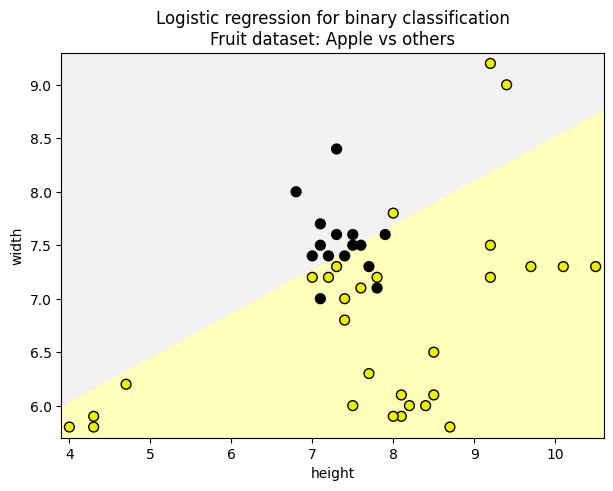

In [ ]:
from sklearn.linear_model import LogisticRegression
from adspy_shared_utilities import (
plot_class_regions_for_classifier_subplot)

fig, subaxes = plt.subplots(1, 1, figsize=(7, 5))
# Se convierte el problema original (multiclase) a binario:
# y_fruits_2d contiene etiquetas 1..4 (apple, mandarin, orange, lemon)
# Aquí se crea una máscara booleana: True si es manzana (label==1), False si no
y_fruits_apple = y_fruits_2d == 1   # make into a binary problem: apples vs everything else
# X_fruits_2d tiene solo dos features: height y width (por eso se puede graficar en 2D)
# .values convierte DataFrame/Series a numpy arrays (lo que espera sklearn)
X_train, X_test, y_train, y_test = (
train_test_split(X_fruits_2d.values,
                y_fruits_apple.values,
                random_state = 0))

# Se crea y entrena el modelo de regresión logística
# C es el inverso de la regularización:
# - C grande (100) -> poca regularización -> modelo más flexible (riesgo de overfitting)
# - C pequeño -> más regularización -> frontera más simple
clf = LogisticRegression(C=100).fit(X_train, y_train)
##Se hace la grafica
plot_class_regions_for_classifier_subplot(clf, X_train, y_train, None,
                                         None, 'Logistic regression \
for binary classification\nFruit dataset: Apple vs others',
                                         subaxes)

# Se prueban predicciones para 2 frutas "nuevas" (height, width)
h = 6
w = 8
# clf.predict devuelve True/False (o 1/0) para "es manzana"
# int(...) lo convierte a 0 o 1 para indexar el texto
print('A fruit with height {} and width {} is predicted to be: {}'
     .format(h,w, ['not an apple', 'an apple'][int(clf.predict([[h,w]])[0])]))

h = 10
w = 7
print('A fruit with height {} and width {} is predicted to be: {}'
     .format(h,w, ['not an apple', 'an apple'][int(clf.predict([[h,w]])[0])]))
subaxes.set_xlabel('height')
subaxes.set_ylabel('width')

print('Accuracy of Logistic regression classifier on training set: {:.2f}'
     .format(clf.score(X_train, y_train)))
print('Accuracy of Logistic regression classifier on test set: {:.2f}'
     .format(clf.score(X_test, y_test)))

#### Logistic regression on simple synthetic dataset

Accuracy of Logistic regression classifier on training set: 0.81
Accuracy of Logistic regression classifier on test set: 0.84


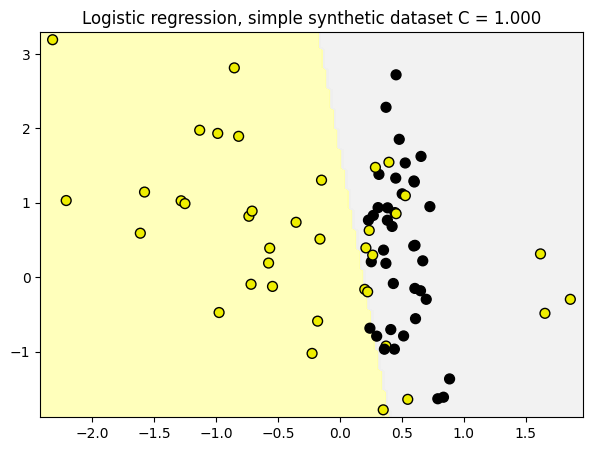

In [17]:
from sklearn.linear_model import LogisticRegression
from adspy_shared_utilities import (
plot_class_regions_for_classifier_subplot)


X_train, X_test, y_train, y_test = train_test_split(X_C2, y_C2,
                                                   random_state = 0)

fig, subaxes = plt.subplots(1, 1, figsize=(7, 5))
clf = LogisticRegression().fit(X_train, y_train)
title = 'Logistic regression, simple synthetic dataset C = {:.3f}'.format(1.0)
plot_class_regions_for_classifier_subplot(clf, X_train, y_train,
                                         None, None, title, subaxes)

print('Accuracy of Logistic regression classifier on training set: {:.2f}'
     .format(clf.score(X_train, y_train)))
print('Accuracy of Logistic regression classifier on test set: {:.2f}'
     .format(clf.score(X_test, y_test)))
     

#### Logistic regression regularization: C parameter

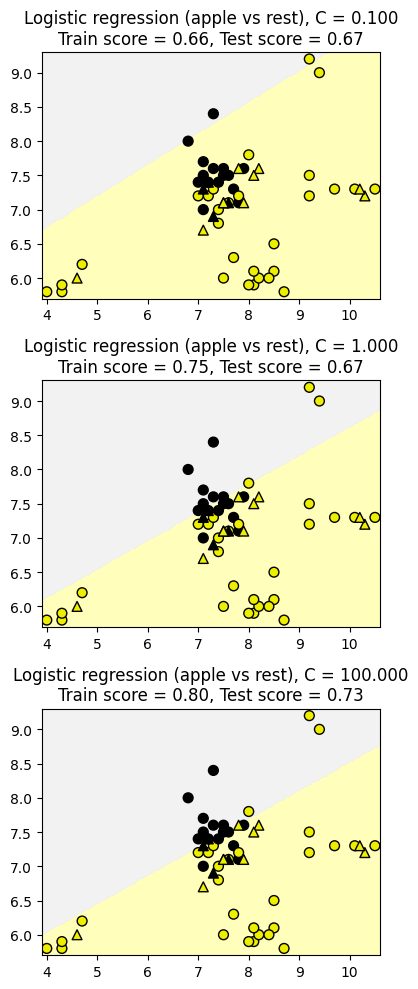

In [18]:
X_train, X_test, y_train, y_test = (
train_test_split(X_fruits_2d.values,
                y_fruits_apple.values,
                random_state=0))

fig, subaxes = plt.subplots(3, 1, figsize=(4, 10))

for this_C, subplot in zip([0.1, 1, 100], subaxes):
    clf = LogisticRegression(C=this_C).fit(X_train, y_train)
    title ='Logistic regression (apple vs rest), C = {:.3f}'.format(this_C)
    
    plot_class_regions_for_classifier_subplot(clf, X_train, y_train,
                                             X_test, y_test, title,
                                             subplot)
plt.tight_layout()

#### Application to real dataset

In [19]:
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, random_state = 0)

clf = LogisticRegression().fit(X_train, y_train)
print('Breast cancer dataset')
print('Accuracy of Logistic regression classifier on training set: {:.2f}'
     .format(clf.score(X_train, y_train)))
print('Accuracy of Logistic regression classifier on test set: {:.2f}'
     .format(clf.score(X_test, y_test)))

Breast cancer dataset
Accuracy of Logistic regression classifier on training set: 0.95
Accuracy of Logistic regression classifier on test set: 0.94


c:\Users\mar_c\OneDrive\Documentos\LosProyectos\Machine Learning\Aprendizaje Automatico\aprendizajeaut\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Support Vector Machines

#### Linear Support Vector Machine

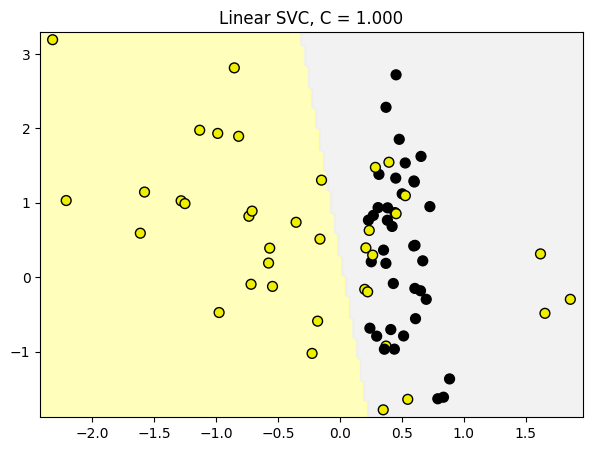

In [20]:
from sklearn.svm import SVC
from adspy_shared_utilities import plot_class_regions_for_classifier_subplot


X_train, X_test, y_train, y_test = train_test_split(X_C2, y_C2, random_state = 0)

fig, subaxes = plt.subplots(1, 1, figsize=(7, 5))
this_C = 1.0
clf = SVC(kernel = 'linear', C=this_C).fit(X_train, y_train)
title = 'Linear SVC, C = {:.3f}'.format(this_C)
plot_class_regions_for_classifier_subplot(clf, X_train, y_train, None, None, title, subaxes)

#### Linear Support Vector Machine: C parameter

c:\Users\mar_c\OneDrive\Documentos\LosProyectos\Machine Learning\Aprendizaje Automatico\aprendizajeaut\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\mar_c\OneDrive\Documentos\LosProyectos\Machine Learning\Aprendizaje Automatico\aprendizajeaut\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\mar_c\OneDrive\Documentos\LosProyectos\Machine Learning\Aprendizaje Automatico\aprendizajeaut\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


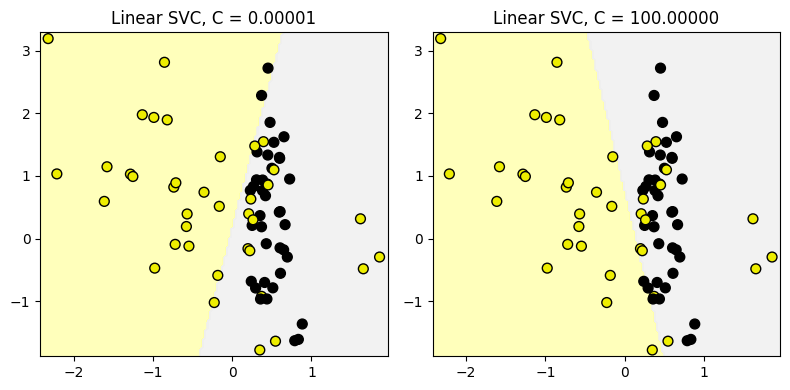

In [21]:
from sklearn.svm import LinearSVC
from adspy_shared_utilities import plot_class_regions_for_classifier

X_train, X_test, y_train, y_test = train_test_split(X_C2, y_C2, random_state = 0)
fig, subaxes = plt.subplots(1, 2, figsize=(8, 4))

for this_C, subplot in zip([0.00001, 100], subaxes):
    clf = LinearSVC(C=this_C).fit(X_train, y_train)
    title = 'Linear SVC, C = {:.5f}'.format(this_C)
    plot_class_regions_for_classifier_subplot(clf, X_train, y_train,
                                             None, None, title, subplot)
plt.tight_layout()

#### Application to real dataset

In [22]:
from sklearn.svm import LinearSVC
X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, random_state = 0)

clf = LinearSVC().fit(X_train, y_train)
print('Breast cancer dataset')
print('Accuracy of Linear SVC classifier on training set: {:.2f}'
     .format(clf.score(X_train, y_train)))
print('Accuracy of Linear SVC classifier on test set: {:.2f}'
     .format(clf.score(X_test, y_test)))

Breast cancer dataset
Accuracy of Linear SVC classifier on training set: 0.92
Accuracy of Linear SVC classifier on test set: 0.94


c:\Users\mar_c\OneDrive\Documentos\LosProyectos\Machine Learning\Aprendizaje Automatico\aprendizajeaut\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\mar_c\OneDrive\Documentos\LosProyectos\Machine Learning\Aprendizaje Automatico\aprendizajeaut\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


### Multi-class classification with linear models

#### LinearSVC with M classes generates M one vs rest classifiers.

In [23]:
from sklearn.svm import LinearSVC

X_train, X_test, y_train, y_test = train_test_split(X_fruits_2d, y_fruits_2d, random_state = 0)

clf = LinearSVC(C=5, random_state = 67).fit(X_train, y_train)
print('Coefficients:\n', clf.coef_)
print('Intercepts:\n', clf.intercept_)

Coefficients:
 [[-0.3   0.72]
 [-1.63  1.16]
 [ 0.01  0.43]
 [ 1.25 -1.64]]
Intercepts:
 [-3.29  1.2  -3.04  1.16]


c:\Users\mar_c\OneDrive\Documentos\LosProyectos\Machine Learning\Aprendizaje Automatico\aprendizajeaut\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\mar_c\OneDrive\Documentos\LosProyectos\Machine Learning\Aprendizaje Automatico\aprendizajeaut\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


#### Multi-class results on the fruit dataset

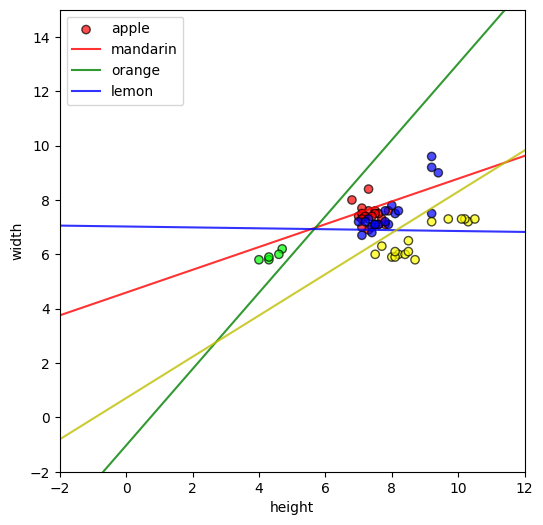

In [24]:
plt.figure(figsize=(6,6))
colors = ['r', 'g', 'b', 'y']
cmap_fruits = ListedColormap(['#FF0000', '#00FF00', '#0000FF','#FFFF00'])

plt.scatter(X_fruits_2d[['height']], X_fruits_2d[['width']],
           c=y_fruits_2d, cmap=cmap_fruits, edgecolor = 'black', alpha=.7)

x_0_range = np.linspace(-10, 15)

for w, b, color in zip(clf.coef_, clf.intercept_, ['r', 'g', 'b', 'y']):
    # Since class prediction with a linear model uses the formula y = w_0 x_0 + w_1 x_1 + b, 
    # and the decision boundary is defined as being all points with y = 0, to plot x_1 as a 
    # function of x_0 we just solve w_0 x_0 + w_1 x_1 + b = 0 for x_1:
    plt.plot(x_0_range, -(x_0_range * w[0] + b) / w[1], c=color, alpha=.8)
    
plt.legend(target_names_fruits)
plt.xlabel('height')
plt.ylabel('width')
plt.xlim(-2, 12)
plt.ylim(-2, 15)
plt.show()

## Kernelized Support Vector Machines

### Classification

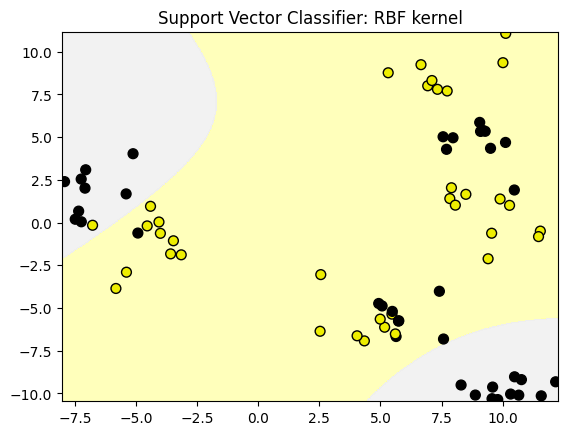

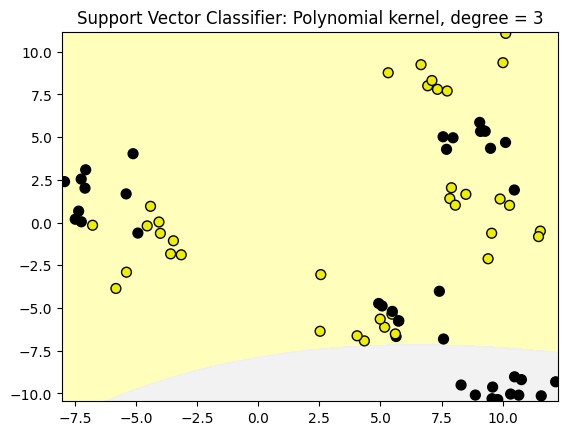

In [25]:
from sklearn.svm import SVC
from adspy_shared_utilities import plot_class_regions_for_classifier

X_train, X_test, y_train, y_test = train_test_split(X_D2, y_D2, random_state = 0)

# The default SVC kernel is radial basis function (RBF)
plot_class_regions_for_classifier(SVC().fit(X_train, y_train),
                                 X_train, y_train, None, None,
                                 'Support Vector Classifier: RBF kernel')

# Compare decision boundries with polynomial kernel, degree = 3
plot_class_regions_for_classifier(SVC(kernel = 'poly', degree = 3)
                                 .fit(X_train, y_train), X_train,
                                 y_train, None, None,
                                 'Support Vector Classifier: Polynomial kernel, degree = 3')

#### Support Vector Machine with RBF kernel: gamma parameter

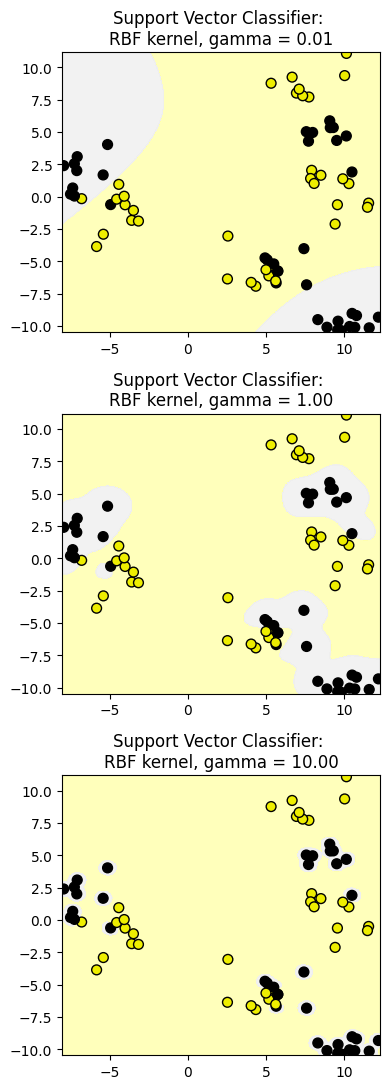

In [26]:
from adspy_shared_utilities import plot_class_regions_for_classifier

X_train, X_test, y_train, y_test = train_test_split(X_D2, y_D2, random_state = 0)
fig, subaxes = plt.subplots(3, 1, figsize=(4, 11))

for this_gamma, subplot in zip([0.01, 1.0, 10.0], subaxes):
    clf = SVC(kernel = 'rbf', gamma=this_gamma).fit(X_train, y_train)
    title = 'Support Vector Classifier: \nRBF kernel, gamma = {:.2f}'.format(this_gamma)
    plot_class_regions_for_classifier_subplot(clf, X_train, y_train,
                                             None, None, title, subplot)
    plt.tight_layout()

#### Support Vector Machine with RBF kernel: using both C and gamma parameter 

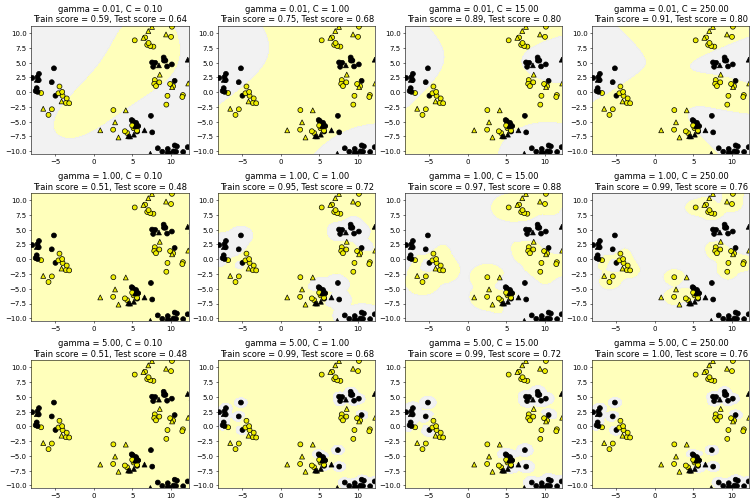

In [27]:
from sklearn.svm import SVC
from adspy_shared_utilities import plot_class_regions_for_classifier_subplot

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X_D2, y_D2, random_state = 0)
fig, subaxes = plt.subplots(3, 4, figsize=(15, 10), dpi=50)

for this_gamma, this_axis in zip([0.01, 1, 5], subaxes):
    
    for this_C, subplot in zip([0.1, 1, 15, 250], this_axis):
        title = 'gamma = {:.2f}, C = {:.2f}'.format(this_gamma, this_C)
        clf = SVC(kernel = 'rbf', gamma = this_gamma,
                 C = this_C).fit(X_train, y_train)
        plot_class_regions_for_classifier_subplot(clf, X_train, y_train,
                                                 X_test, y_test, title,
                                                 subplot)
        plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)

### Application of SVMs to a real dataset: unnormalized data

In [28]:
from sklearn.svm import SVC
X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer,
                                                   random_state = 0)

clf = SVC(C=10).fit(X_train, y_train)
print('Breast cancer dataset (unnormalized features)')
print('Accuracy of RBF-kernel SVC on training set: {:.2f}'
     .format(clf.score(X_train, y_train)))
print('Accuracy of RBF-kernel SVC on test set: {:.2f}'
     .format(clf.score(X_test, y_test)))

Breast cancer dataset (unnormalized features)
Accuracy of RBF-kernel SVC on training set: 0.92
Accuracy of RBF-kernel SVC on test set: 0.94


### Application of SVMs to a real dataset: normalized data with feature preprocessing using minmax scaling

In [29]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = SVC(C=10).fit(X_train_scaled, y_train)
print('Breast cancer dataset (normalized with MinMax scaling)')
print('RBF-kernel SVC (with MinMax scaling) training set accuracy: {:.2f}'
     .format(clf.score(X_train_scaled, y_train)))
print('RBF-kernel SVC (with MinMax scaling) test set accuracy: {:.2f}'
     .format(clf.score(X_test_scaled, y_test)))

Breast cancer dataset (normalized with MinMax scaling)
RBF-kernel SVC (with MinMax scaling) training set accuracy: 0.99
RBF-kernel SVC (with MinMax scaling) test set accuracy: 0.97


## Cross-validation

### Example based on k-NN classifier with fruit dataset (2 features)

In [30]:
from sklearn.model_selection import cross_val_score

clf = KNeighborsClassifier(n_neighbors = 5)
X = X_fruits_2d.values
y = y_fruits_2d.values
cv_scores = cross_val_score(clf, X, y)

print('Cross-validation scores (3-fold):', cv_scores)
print('Mean cross-validation score (3-fold): {:.3f}'
     .format(np.mean(cv_scores)))

Cross-validation scores (3-fold): [0.75 0.75 0.83 0.83 0.82]
Mean cross-validation score (3-fold): 0.797


### A note on performing cross-validation for more advanced scenarios.

In some cases (e.g. when feature values have very different ranges), we've seen the need to scale or normalize the training and test sets before use with a classifier. The proper way to do cross-validation when you need to scale the data is *not* to scale the entire dataset with a single transform, since this will indirectly leak information into the training data about the whole dataset, including the test data (see the lecture on data leakage later in the course).  Instead, scaling/normalizing must be computed and applied for each cross-validation fold separately.  To do this, the easiest way in scikit-learn is to use *pipelines*.  While these are beyond the scope of this course, further information is available in the scikit-learn documentation here:

http://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html

or the Pipeline section in the recommended textbook: Introduction to Machine Learning with Python by Andreas C. Müller and Sarah Guido (O'Reilly Media).

## Validation curve example

In [31]:
from sklearn.svm import SVC
from sklearn.model_selection import validation_curve

param_range = np.logspace(-3, 3, 4)
train_scores, test_scores = validation_curve(SVC(), X, y,
                                            param_name='gamma',
                                            param_range=param_range, cv=3)

In [32]:
print(train_scores)

[[0.46 0.44 0.42]
 [0.85 0.72 0.75]
 [0.92 0.9  0.93]
 [1.   1.   0.97]]


In [33]:
print(test_scores)

[[0.5  0.3  0.32]
 [0.85 0.7  0.63]
 [0.55 0.85 0.68]
 [0.4  0.2  0.37]]


<>:11: SyntaxWarning: invalid escape sequence '\g'
<>:11: SyntaxWarning: invalid escape sequence '\g'
C:\Users\mar_c\AppData\Local\Temp\ipykernel_2384\4077656260.py:11: SyntaxWarning: invalid escape sequence '\g'
  plt.xlabel('$\gamma$ (gamma)')


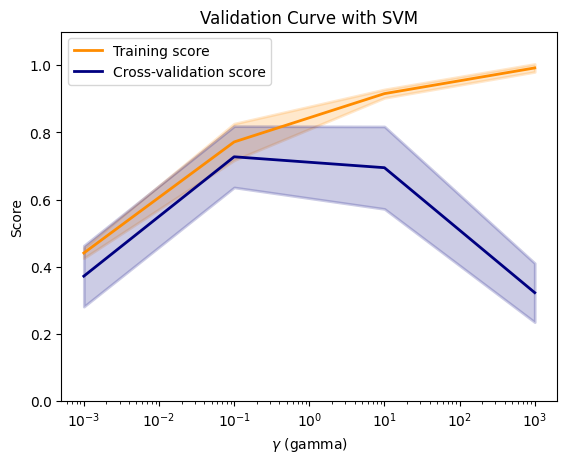

In [34]:
# This code based on scikit-learn validation_plot example
#  See:  http://scikit-learn.org/stable/auto_examples/model_selection/plot_validation_curve.html
plt.figure()

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.title('Validation Curve with SVM')
plt.xlabel('$\gamma$ (gamma)')
plt.ylabel('Score')
plt.ylim(0.0, 1.1)
lw = 2

plt.semilogx(param_range, train_scores_mean, label='Training score',
            color='darkorange', lw=lw)

plt.fill_between(param_range, train_scores_mean - train_scores_std,
                train_scores_mean + train_scores_std, alpha=0.2,
                color='darkorange', lw=lw)

plt.semilogx(param_range, test_scores_mean, label='Cross-validation score',
            color='navy', lw=lw)

plt.fill_between(param_range, test_scores_mean - test_scores_std,
                test_scores_mean + test_scores_std, alpha=0.2,
                color='navy', lw=lw)

plt.legend(loc='best')
plt.show()

## Decision Trees

In [35]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from adspy_shared_utilities import plot_decision_tree
from sklearn.model_selection import train_test_split


iris = load_iris()

X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state = 3)
clf = DecisionTreeClassifier().fit(X_train, y_train)

print('Accuracy of Decision Tree classifier on training set: {:.2f}'
     .format(clf.score(X_train, y_train)))
print('Accuracy of Decision Tree classifier on test set: {:.2f}'
     .format(clf.score(X_test, y_test)))

Accuracy of Decision Tree classifier on training set: 1.00
Accuracy of Decision Tree classifier on test set: 0.95


#### Setting max decision tree depth to help avoid overfitting

In [36]:
clf2 = DecisionTreeClassifier(max_depth = 3).fit(X_train, y_train)

print('Accuracy of Decision Tree classifier on training set: {:.2f}'
     .format(clf2.score(X_train, y_train)))
print('Accuracy of Decision Tree classifier on test set: {:.2f}'
     .format(clf2.score(X_test, y_test)))

Accuracy of Decision Tree classifier on training set: 0.98
Accuracy of Decision Tree classifier on test set: 0.97


#### Visualizing decision trees

In [37]:
plot_decision_tree(clf, iris.feature_names, iris.target_names)

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

#### Pre-pruned version (max_depth = 3)

In [38]:
plot_decision_tree(clf2, iris.feature_names, iris.target_names)

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

#### Feature importance

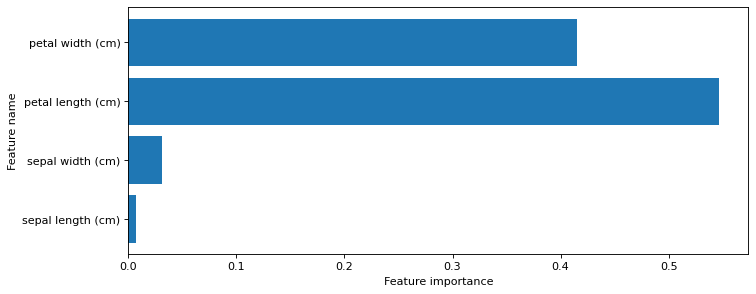

Feature importances: [0.01 0.03 0.55 0.42]


In [39]:
from adspy_shared_utilities import plot_feature_importances

plt.figure(figsize=(10,4), dpi=80)
plot_feature_importances(clf, iris.feature_names)
plt.show()

print('Feature importances: {}'.format(clf.feature_importances_))

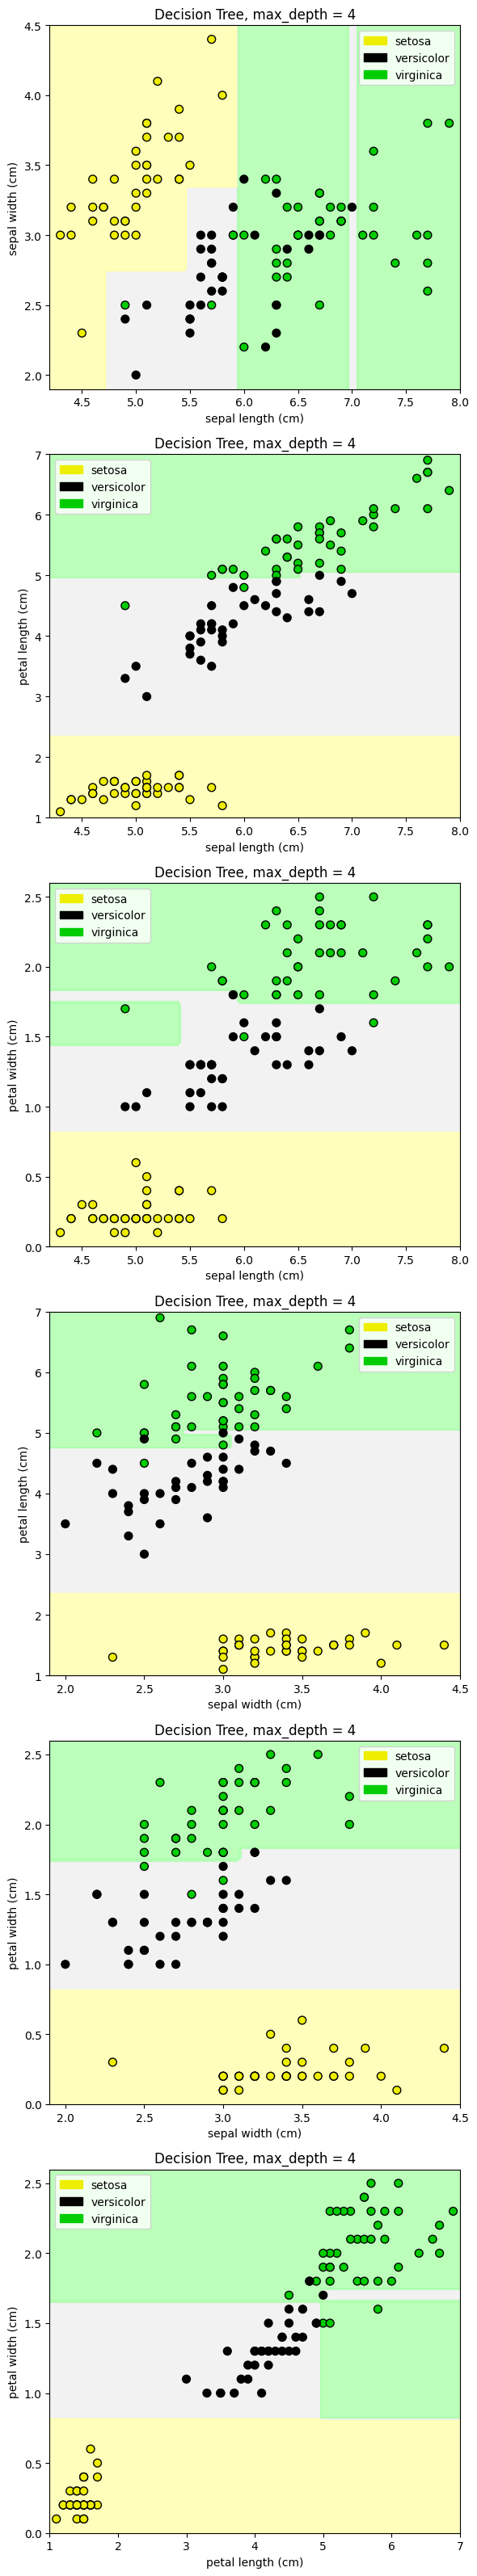

In [40]:
from sklearn.tree import DecisionTreeClassifier
from adspy_shared_utilities import plot_class_regions_for_classifier_subplot

X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state = 0)
fig, subaxes = plt.subplots(6, 1, figsize=(6, 32))

pair_list = [[0,1], [0,2], [0,3], [1,2], [1,3], [2,3]]
tree_max_depth = 4

for pair, axis in zip(pair_list, subaxes):
    X = X_train[:, pair]
    y = y_train
    
    clf = DecisionTreeClassifier(max_depth=tree_max_depth).fit(X, y)
    title = 'Decision Tree, max_depth = {:d}'.format(tree_max_depth)
    plot_class_regions_for_classifier_subplot(clf, X, y, None,
                                             None, title, axis,
                                             iris.target_names)
    
    axis.set_xlabel(iris.feature_names[pair[0]])
    axis.set_ylabel(iris.feature_names[pair[1]])
    
plt.tight_layout()
plt.show()

#### Decision Trees on a real-world dataset

In [41]:
from sklearn.tree import DecisionTreeClassifier
from adspy_shared_utilities import plot_decision_tree
from adspy_shared_utilities import plot_feature_importances

X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, random_state = 0)

clf = DecisionTreeClassifier(max_depth = 4, min_samples_leaf = 8,
                            random_state = 0).fit(X_train, y_train)

plot_decision_tree(clf, cancer.feature_names, cancer.target_names)

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

Breast cancer dataset: decision tree
Accuracy of DT classifier on training set: 0.96
Accuracy of DT classifier on test set: 0.94


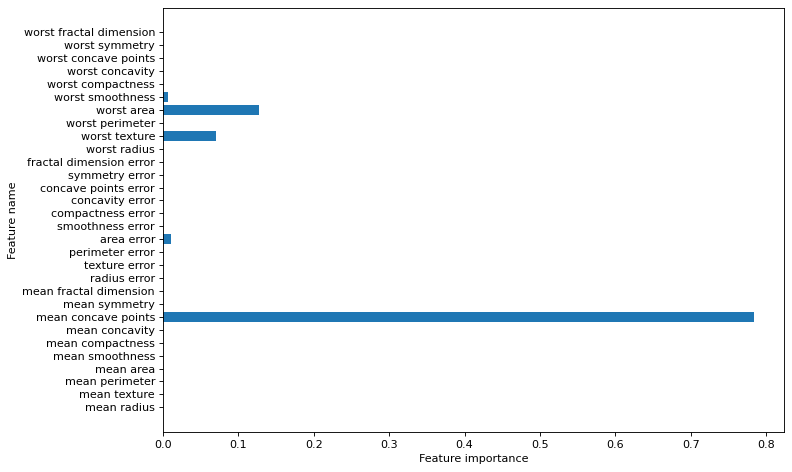

In [42]:
print('Breast cancer dataset: decision tree')
print('Accuracy of DT classifier on training set: {:.2f}'
     .format(clf.score(X_train, y_train)))
print('Accuracy of DT classifier on test set: {:.2f}'
     .format(clf.score(X_test, y_test)))

plt.figure(figsize=(10,6),dpi=80)
plot_feature_importances(clf, cancer.feature_names)
plt.tight_layout()

plt.show()